## grid search 後的資料分析

### 觀察Benign(0), malignant(1) 兩類別在每個radiomics feature的kde分布

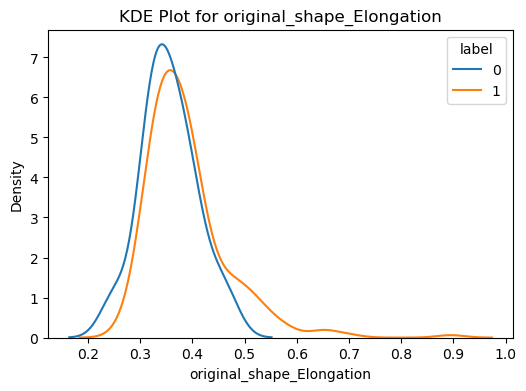

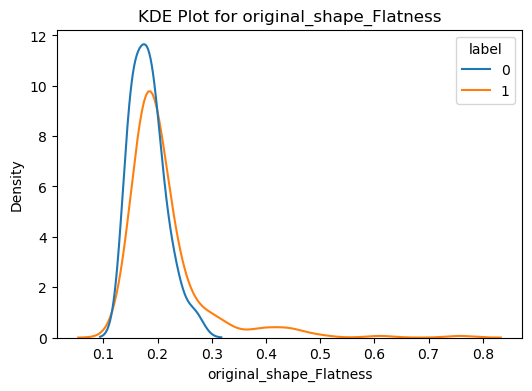

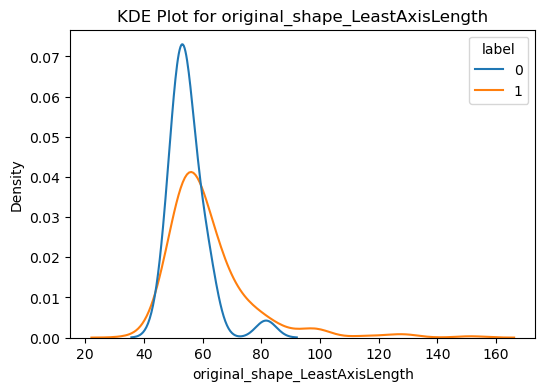

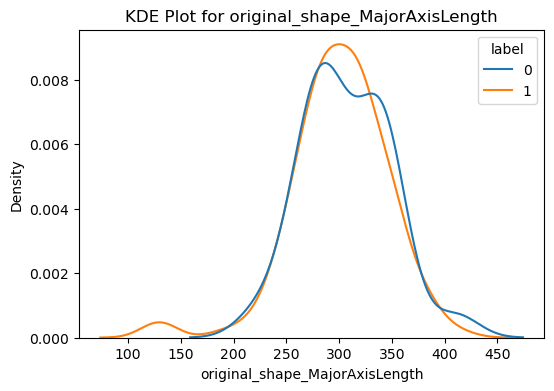

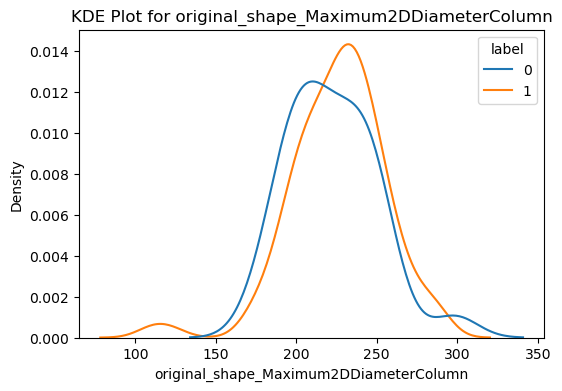

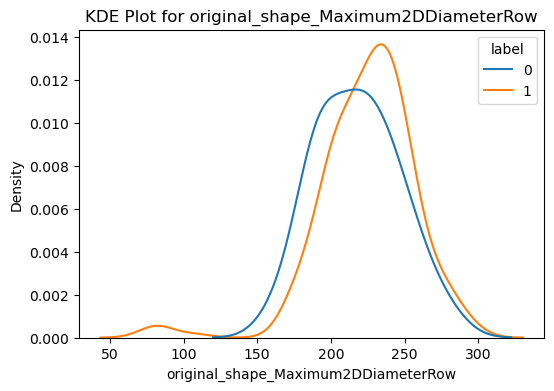

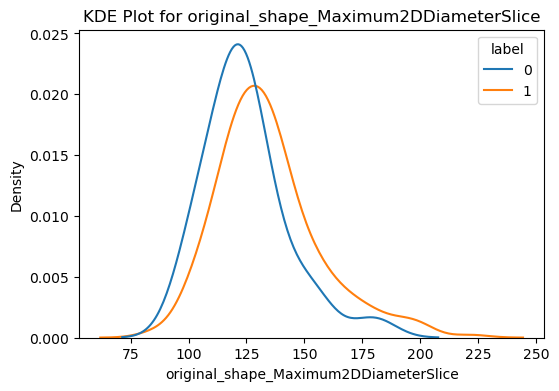

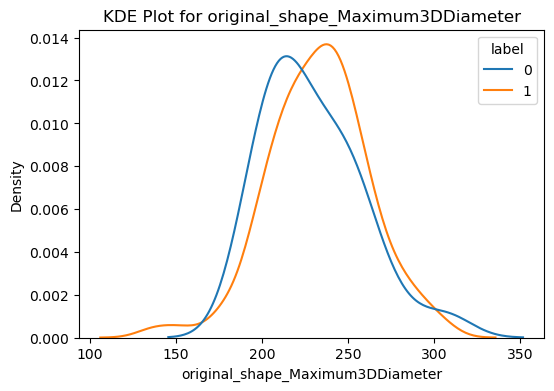

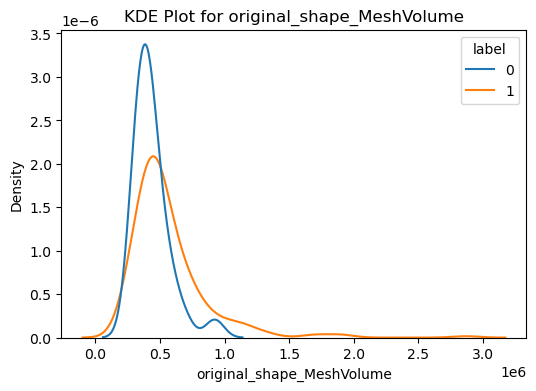

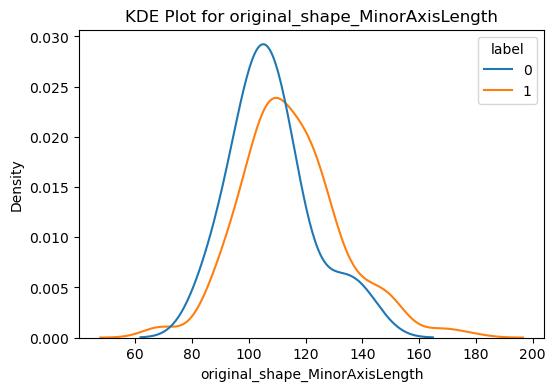

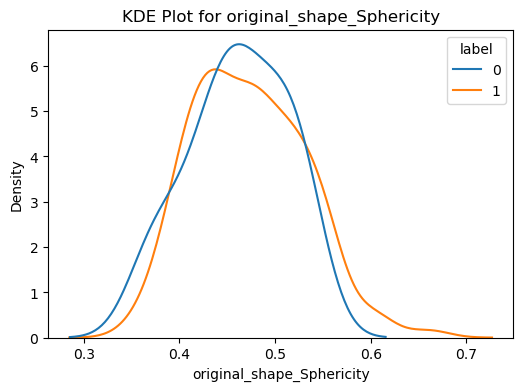

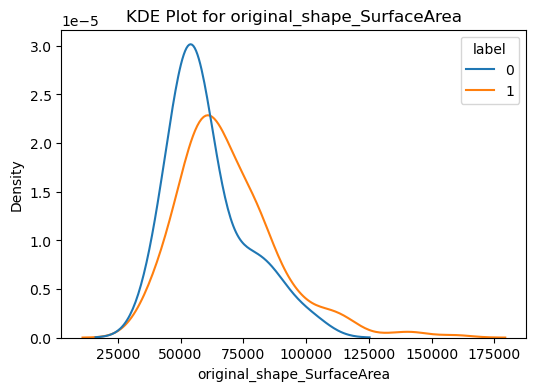

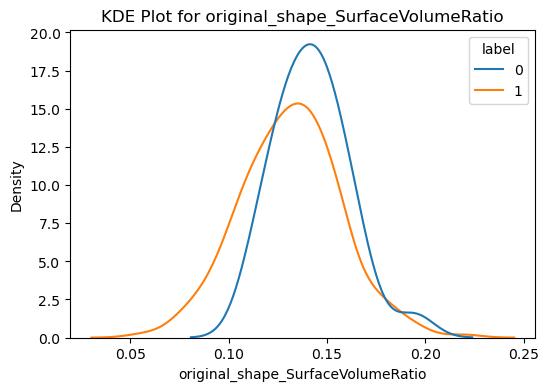

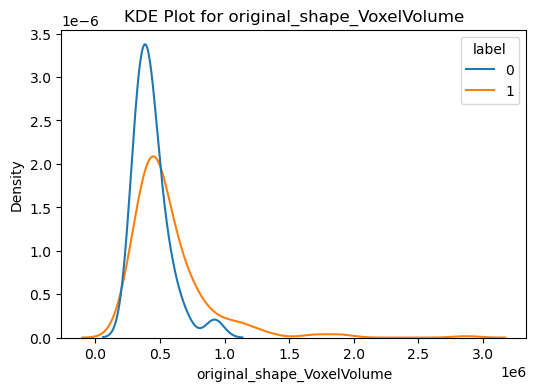

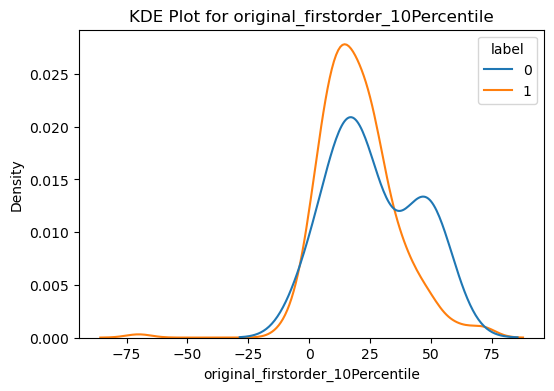

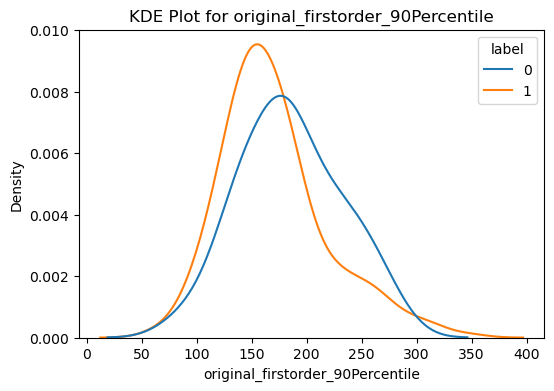

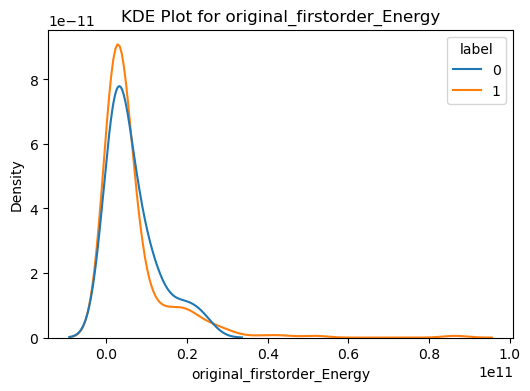

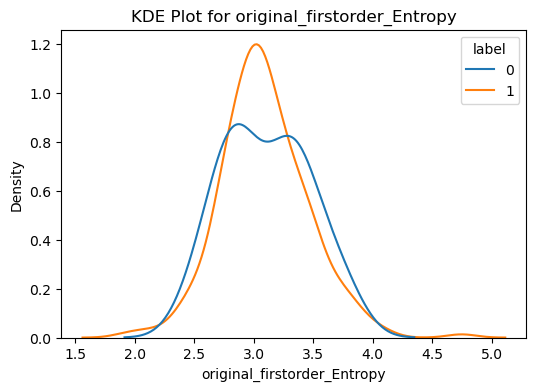

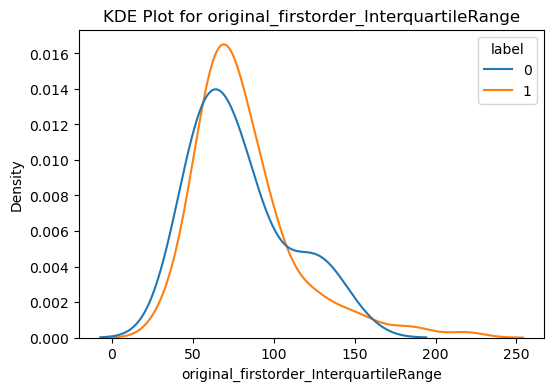

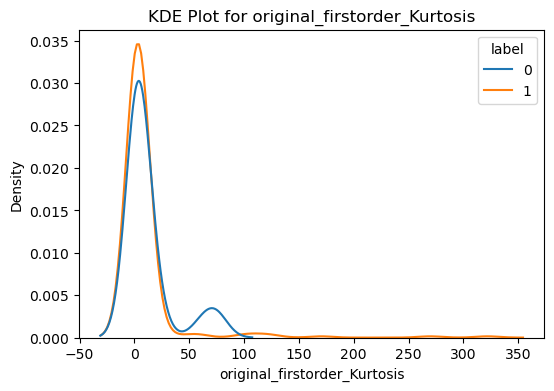

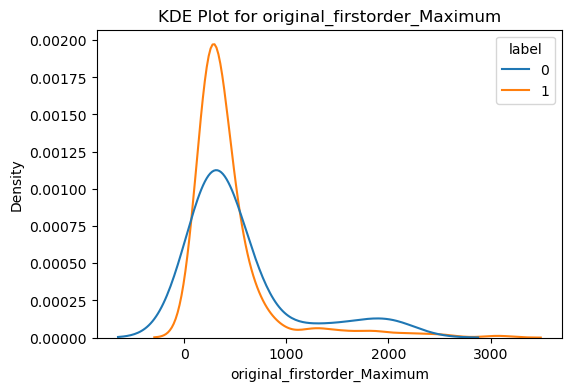

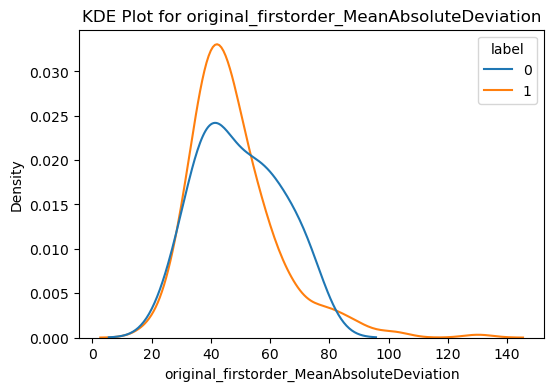

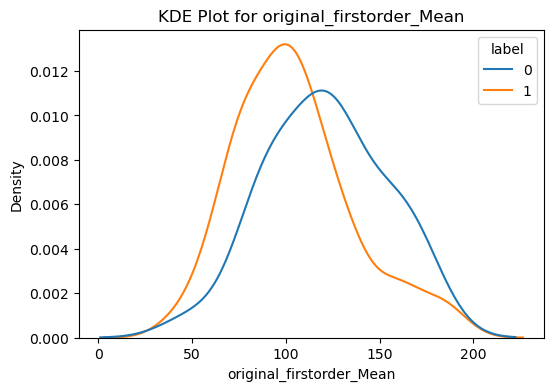

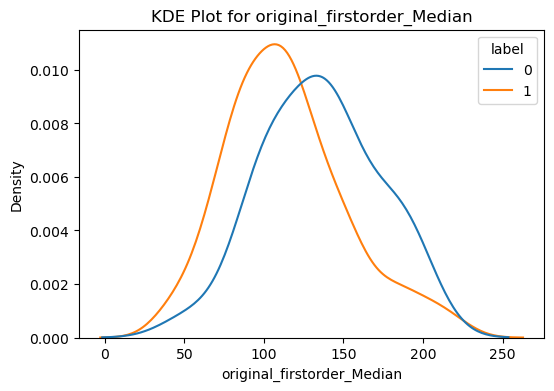

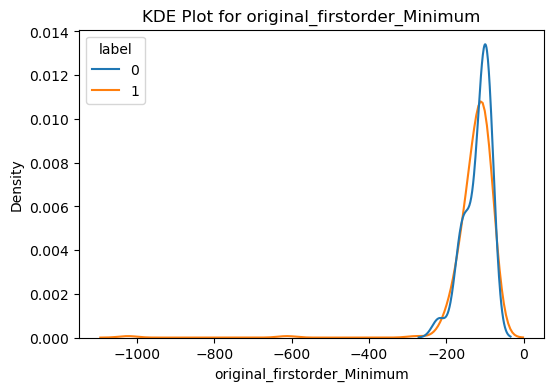

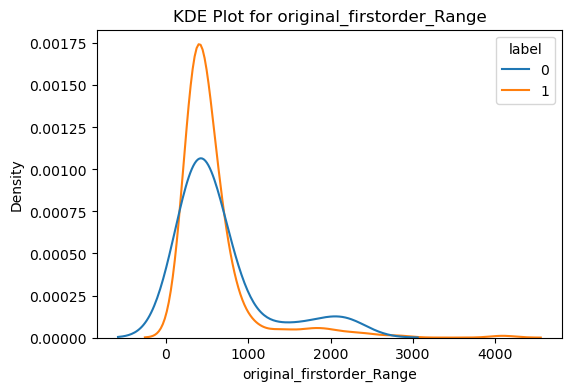

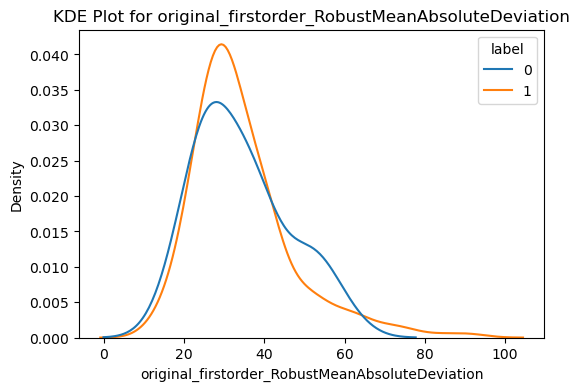

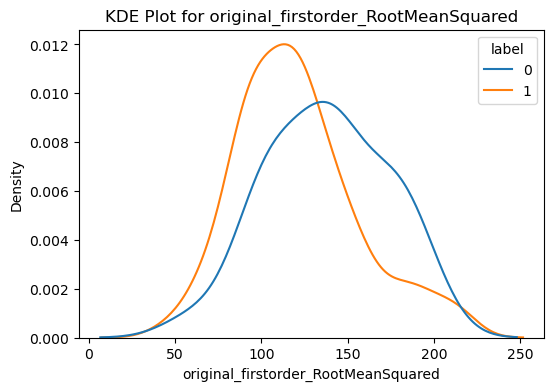

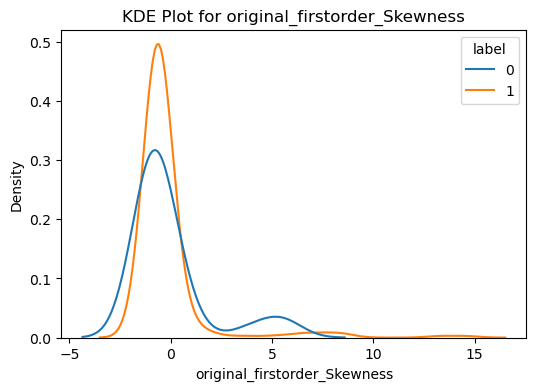

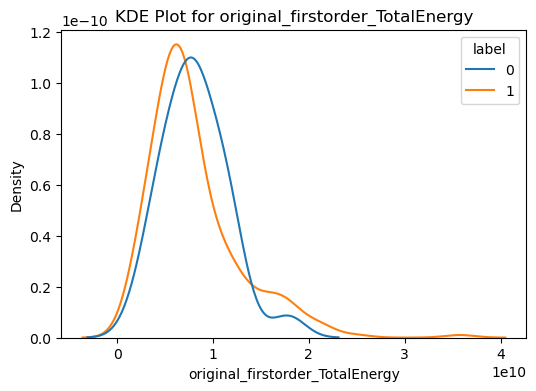

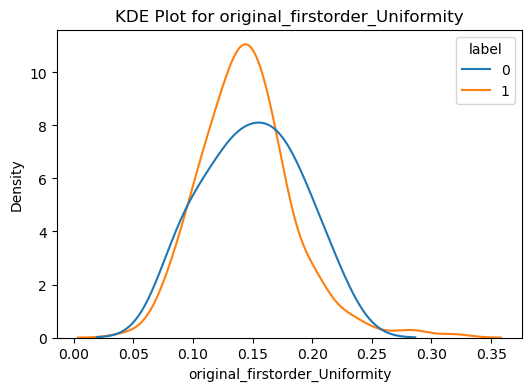

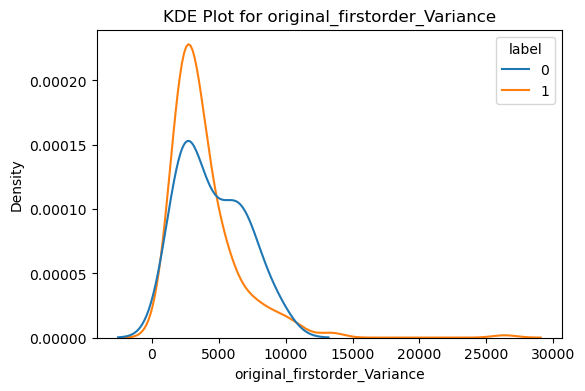

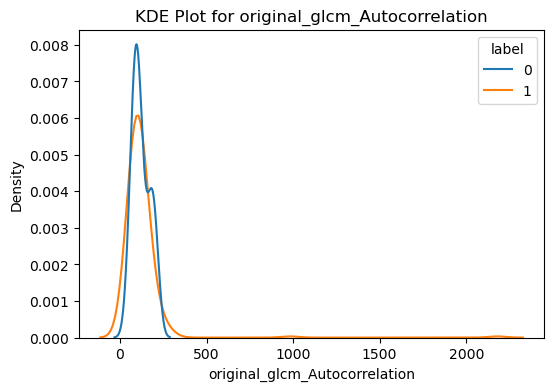

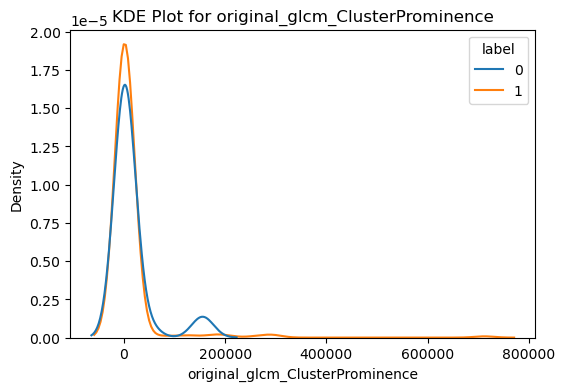

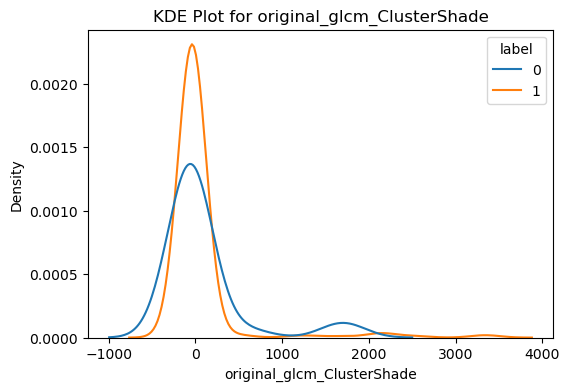

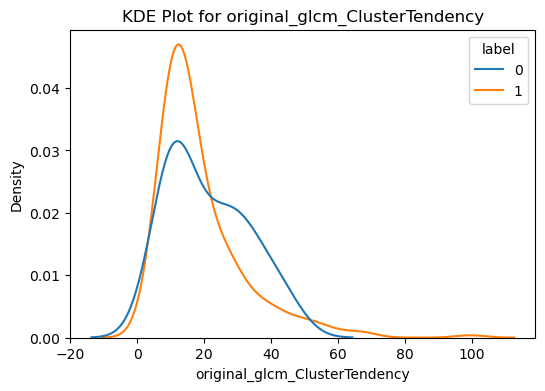

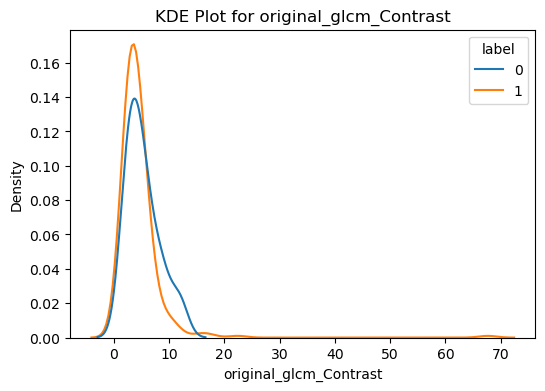

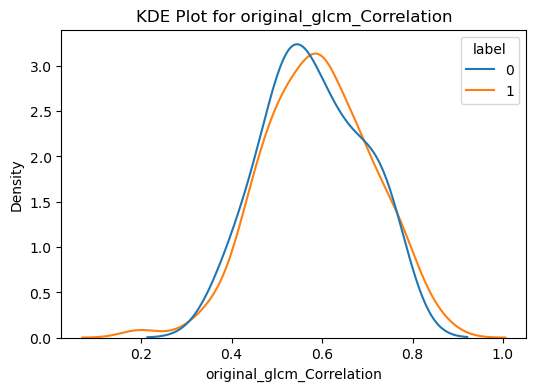

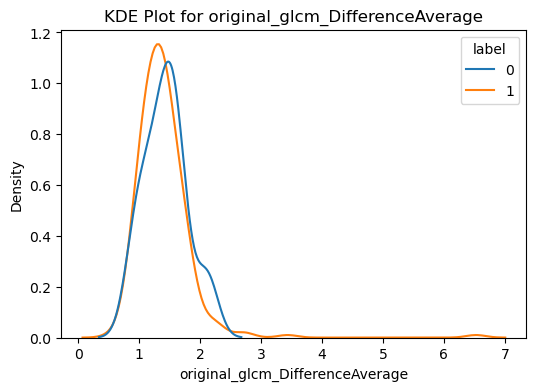

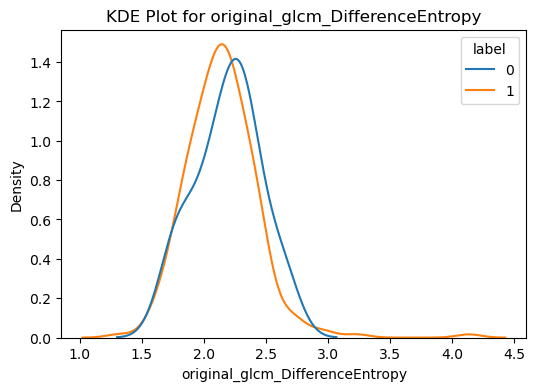

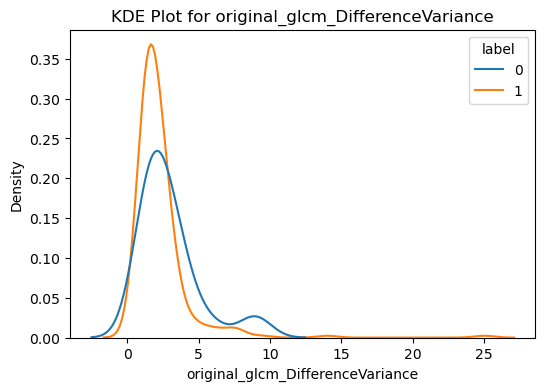

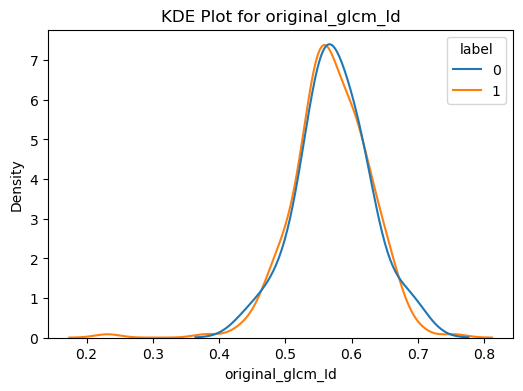

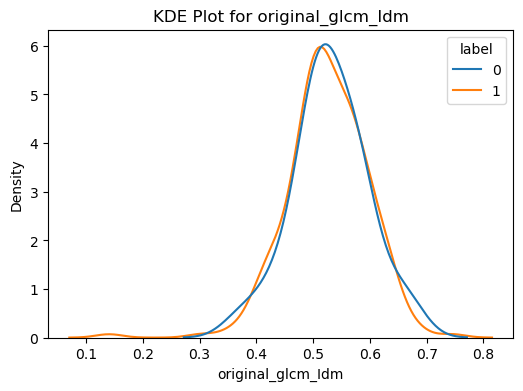

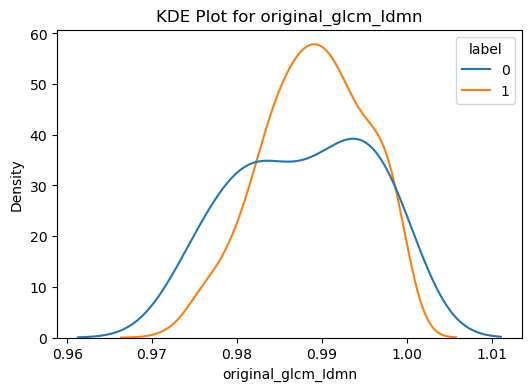

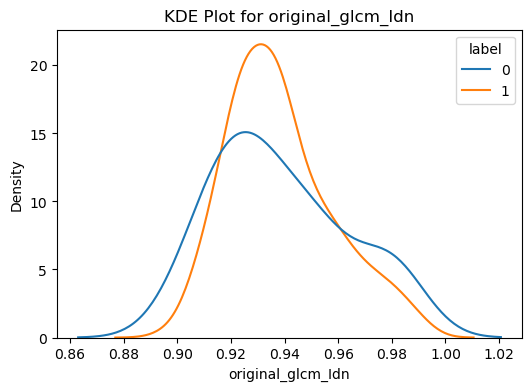

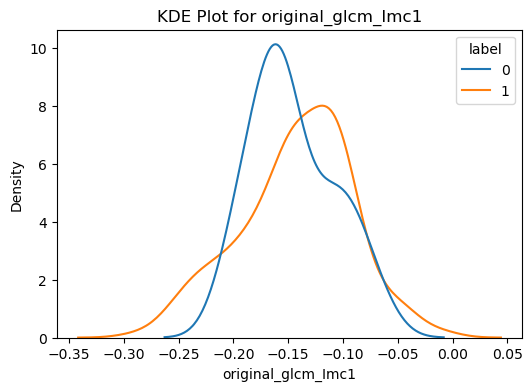

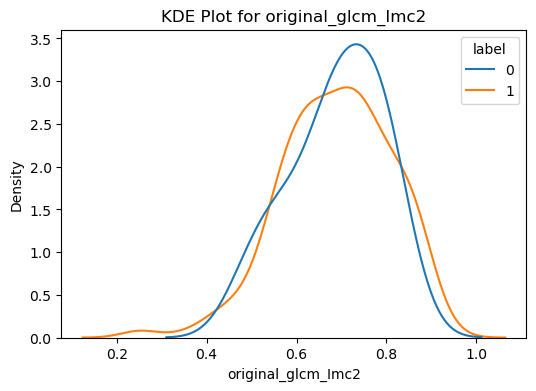

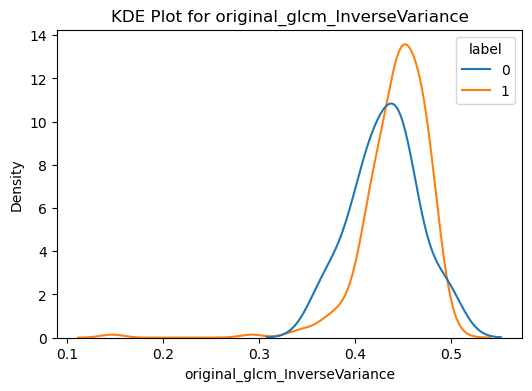

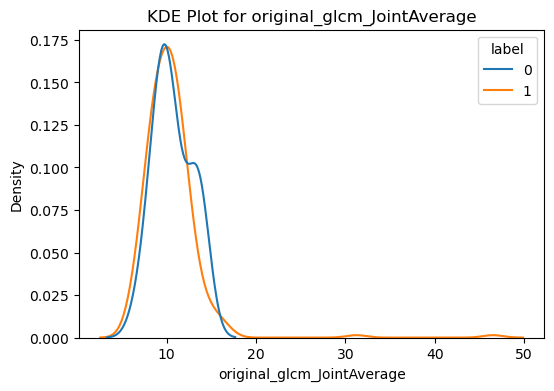

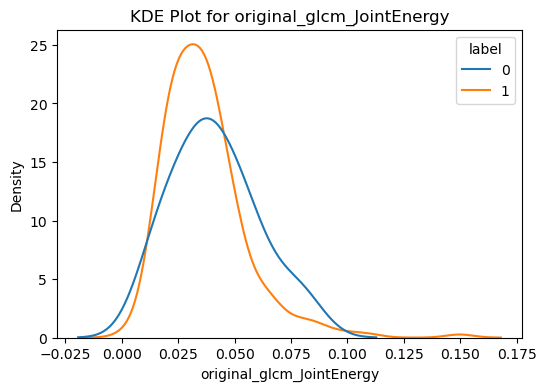

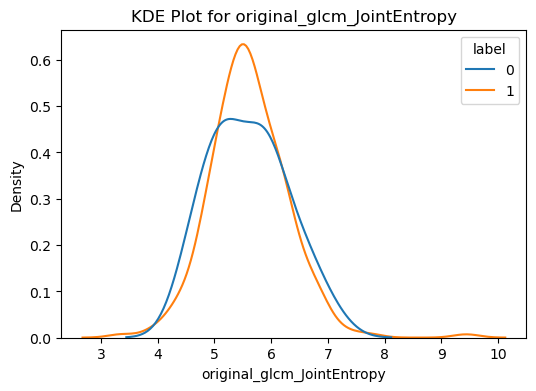

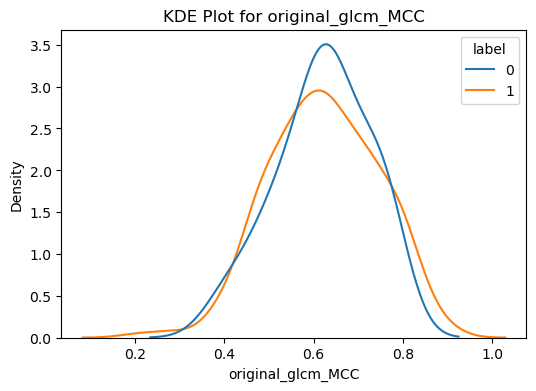

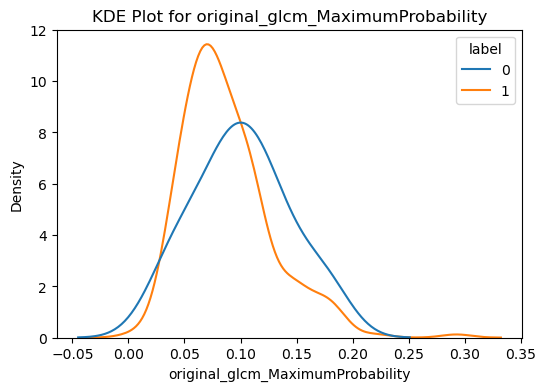

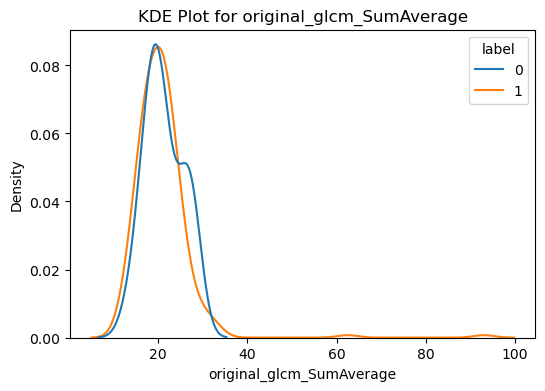

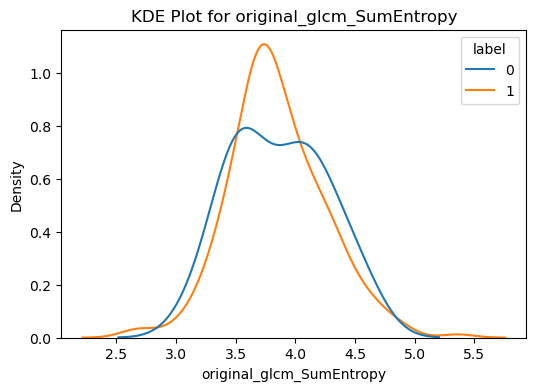

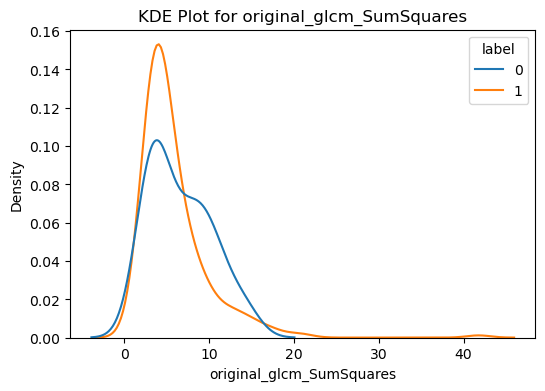

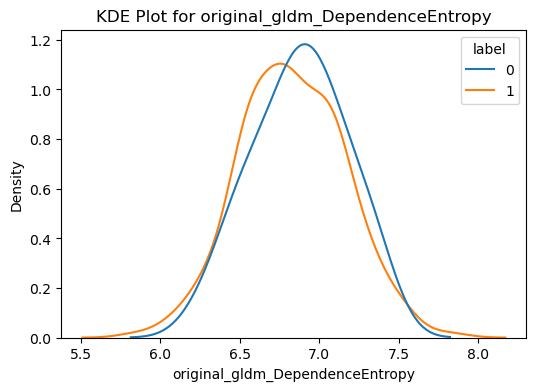

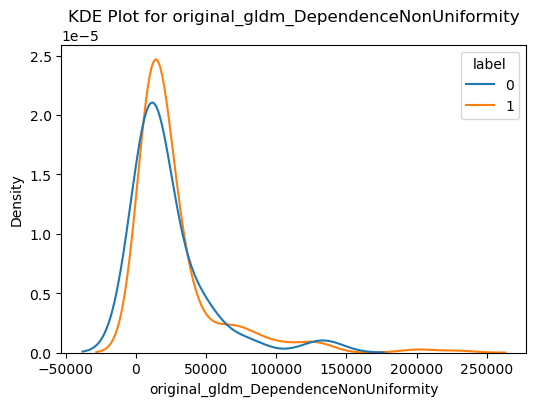

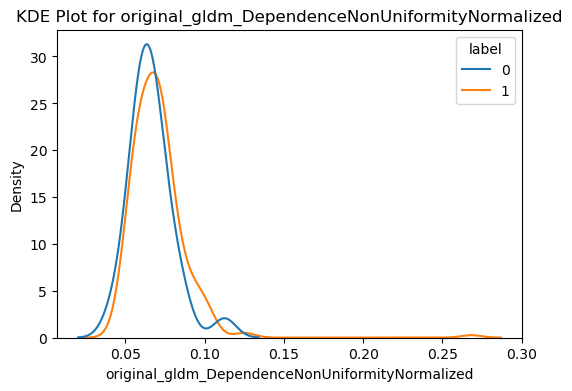

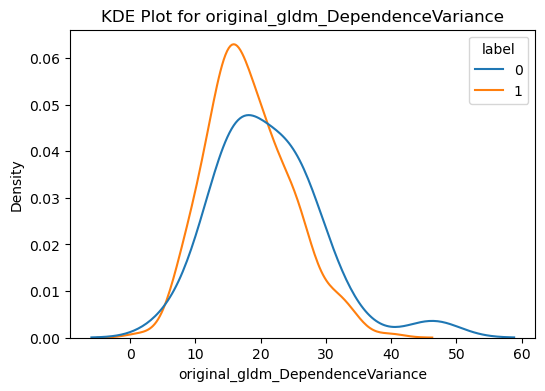

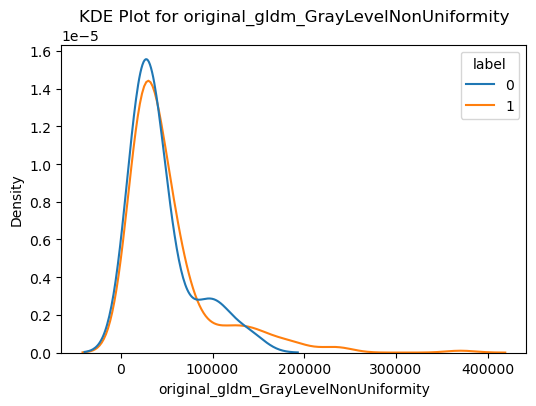

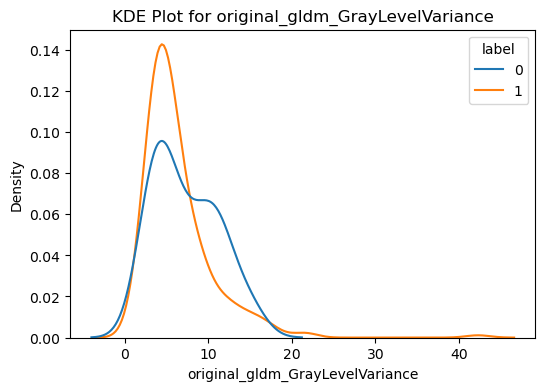

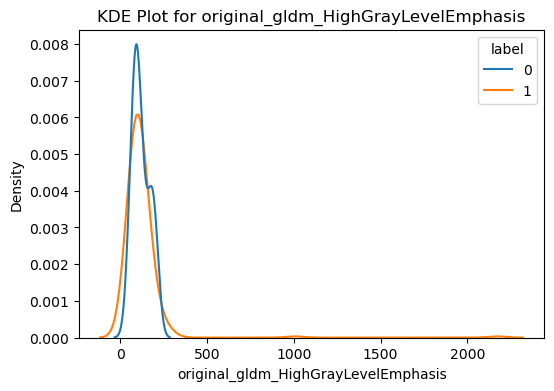

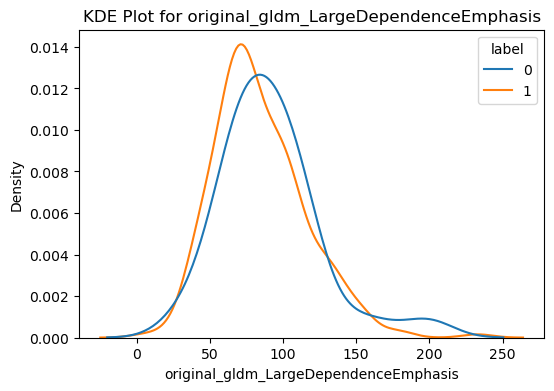

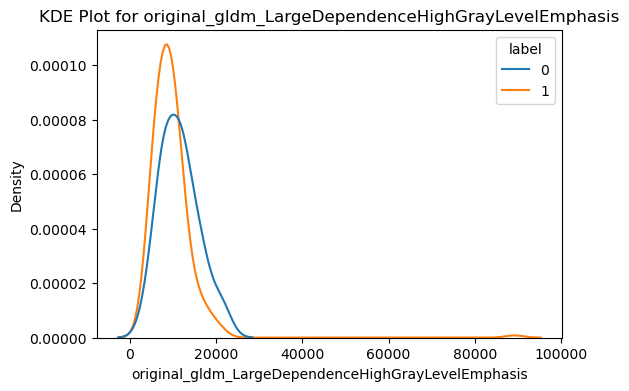

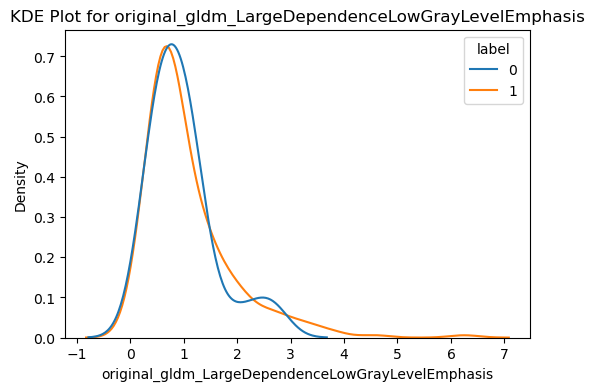

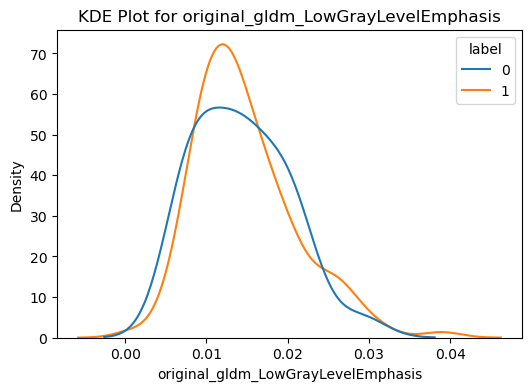

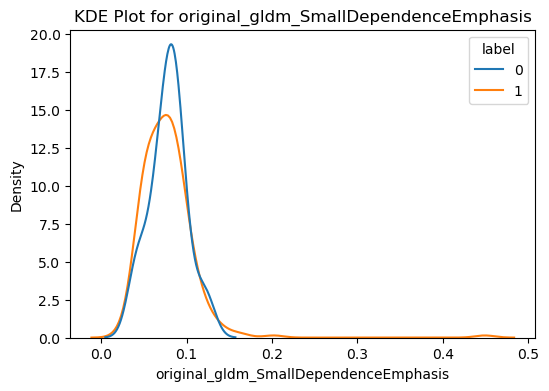

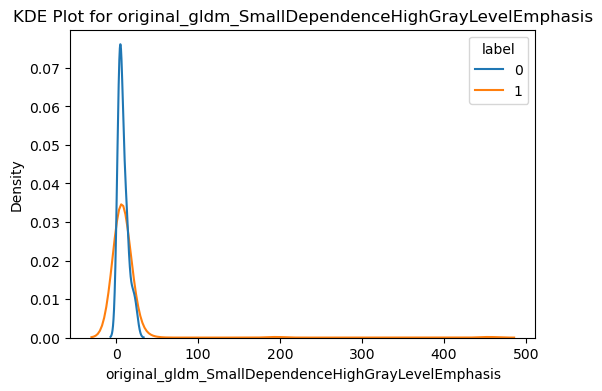

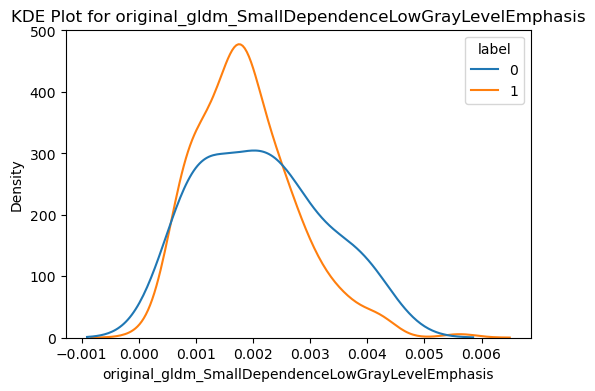

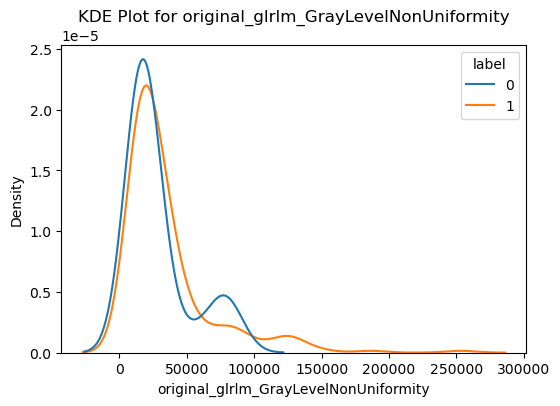

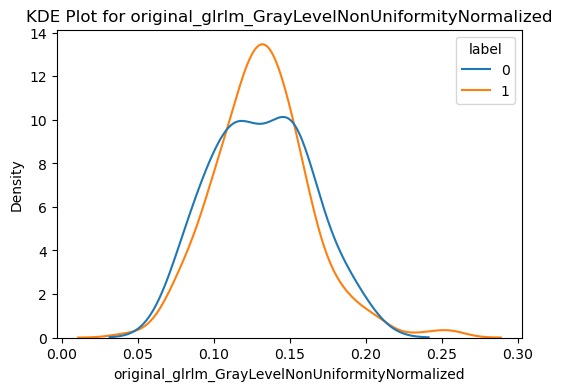

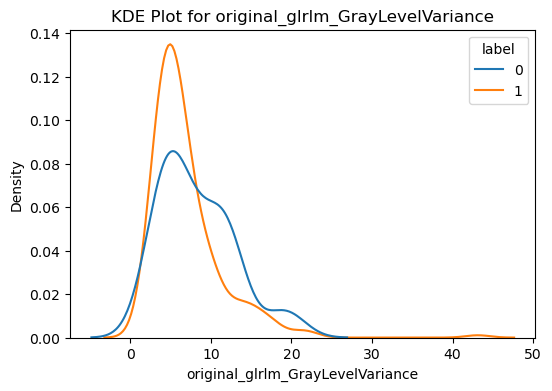

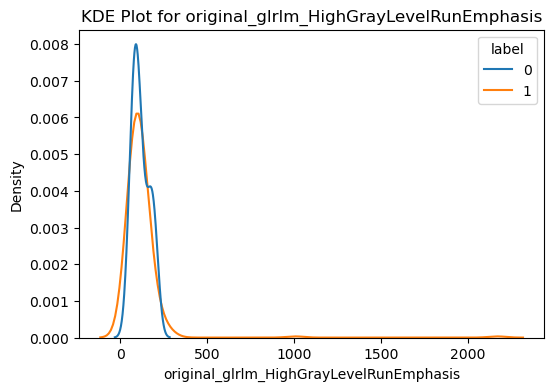

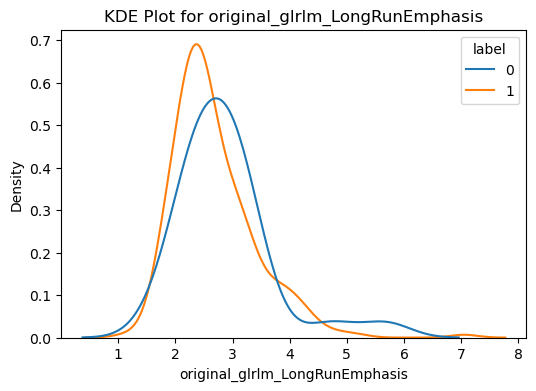

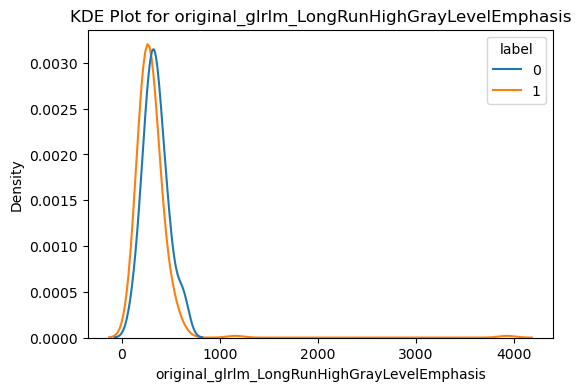

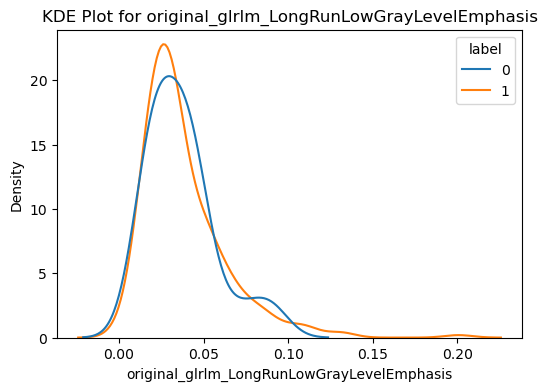

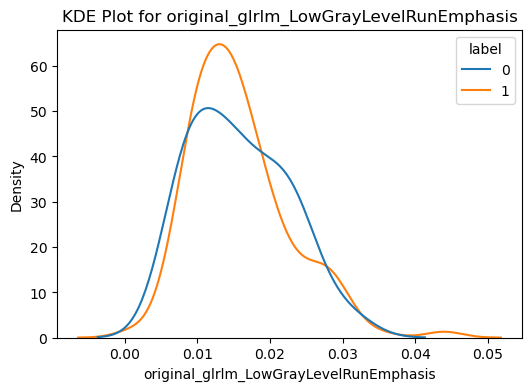

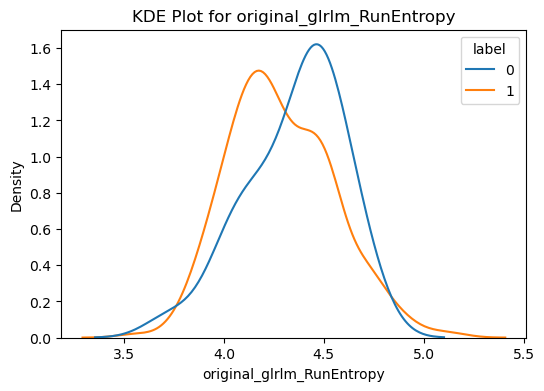

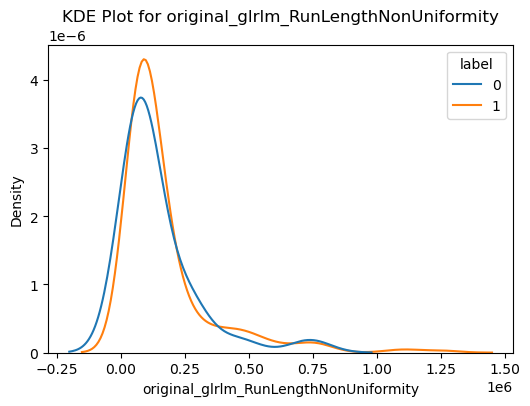

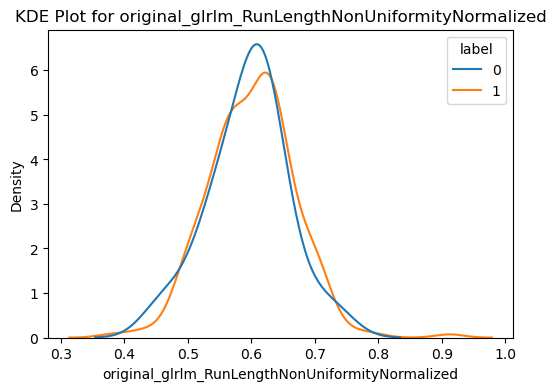

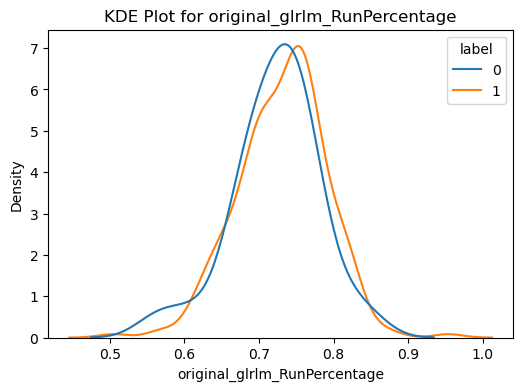

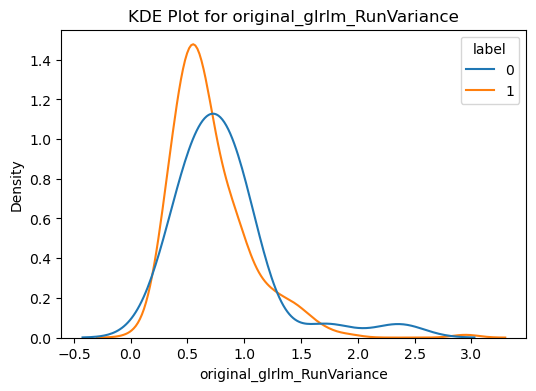

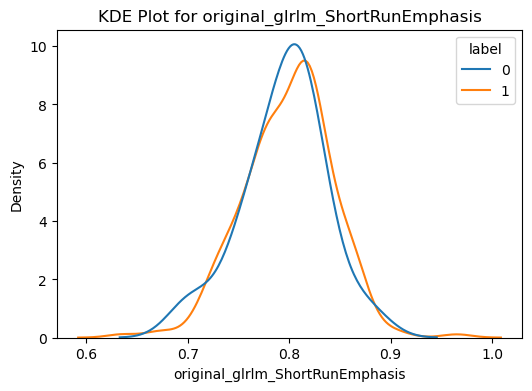

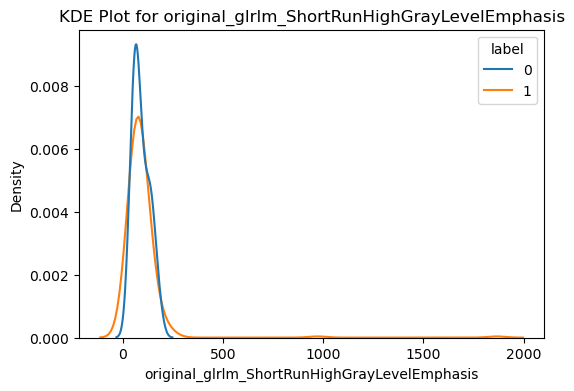

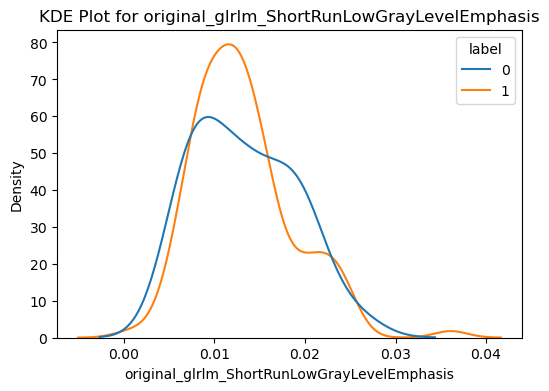

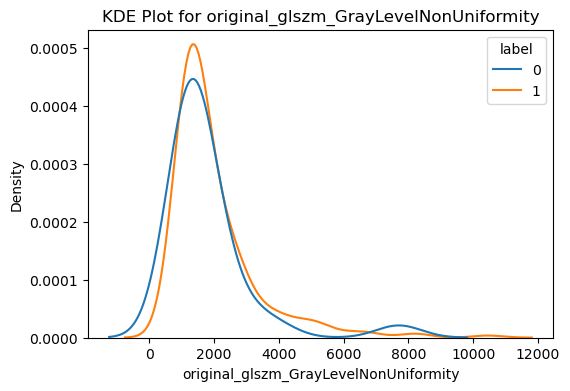

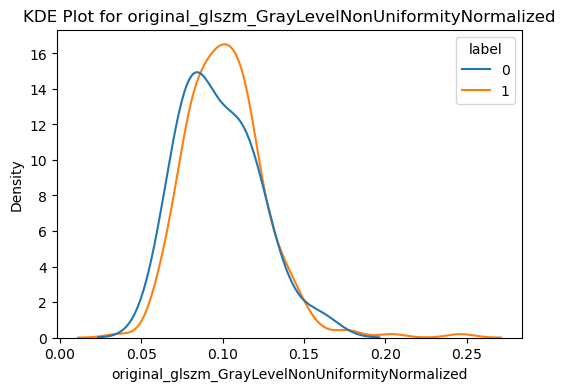

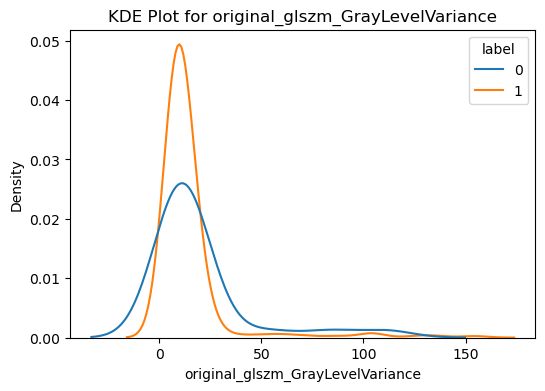

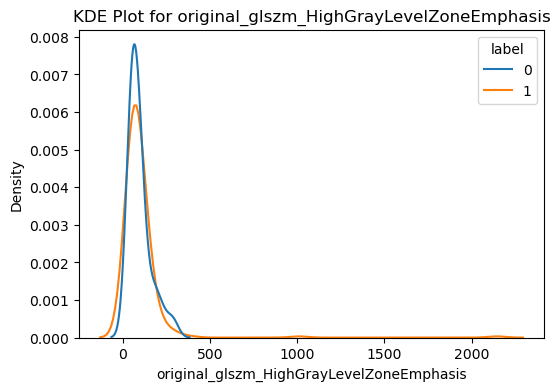

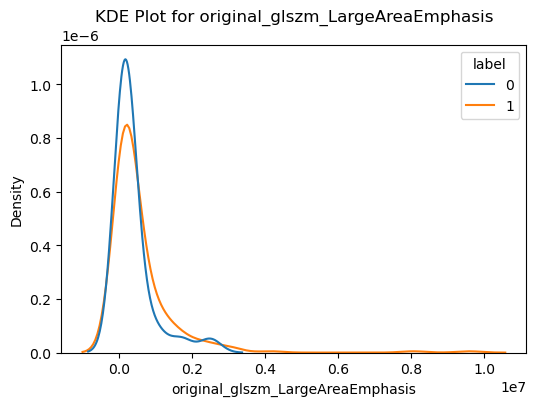

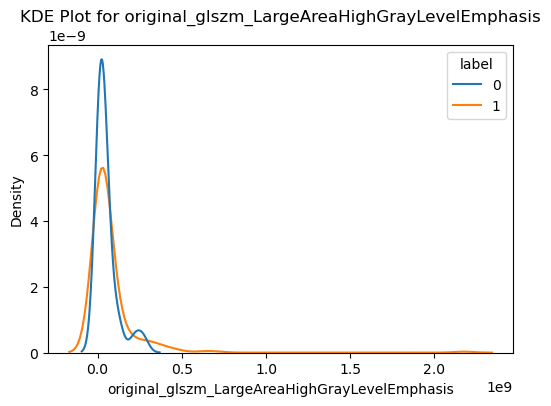

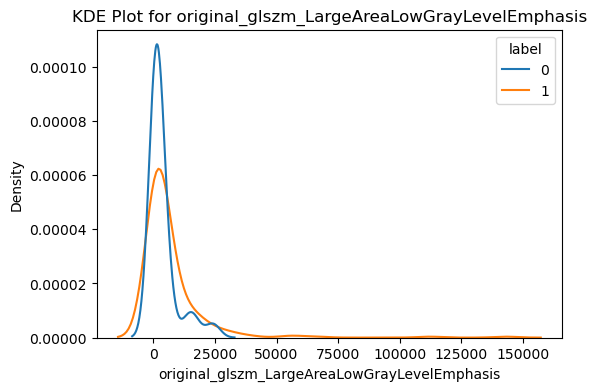

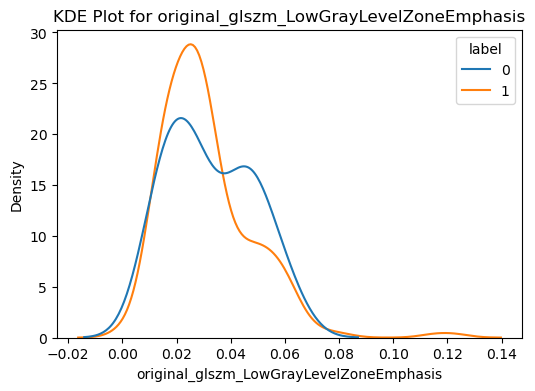

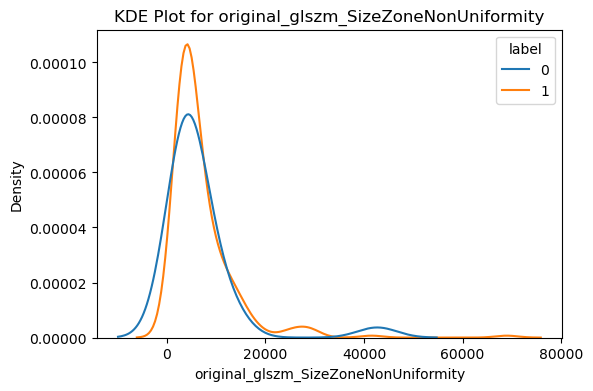

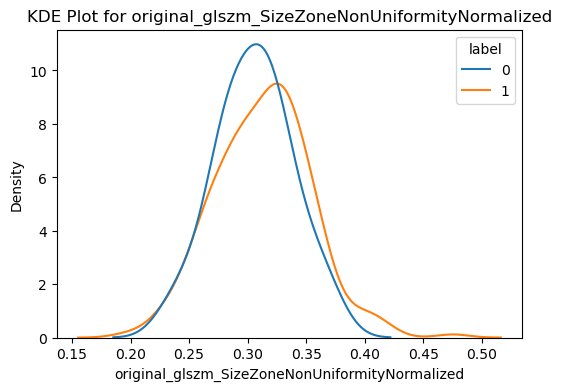

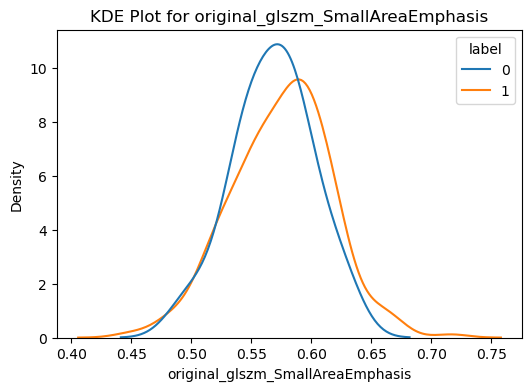

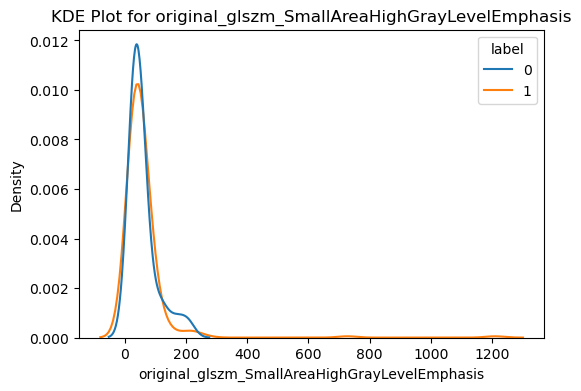

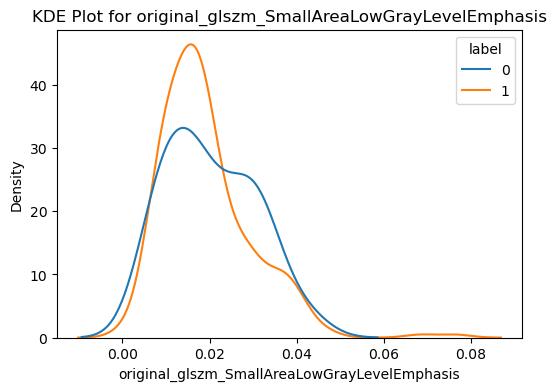

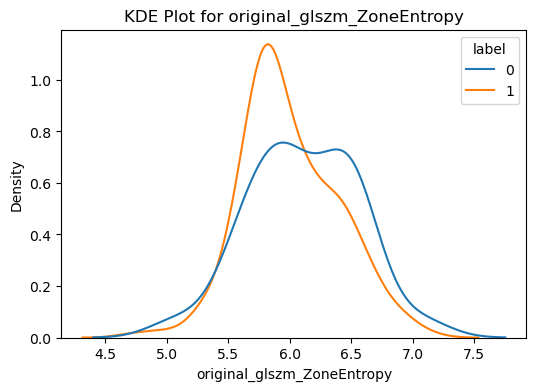

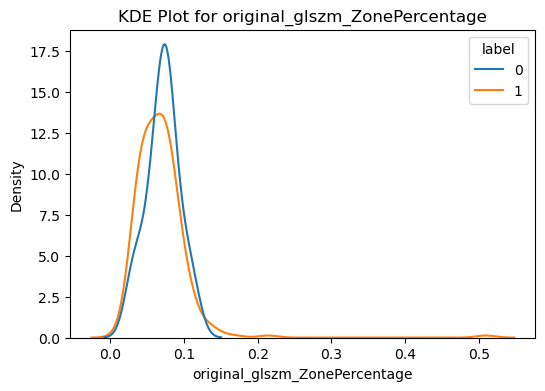

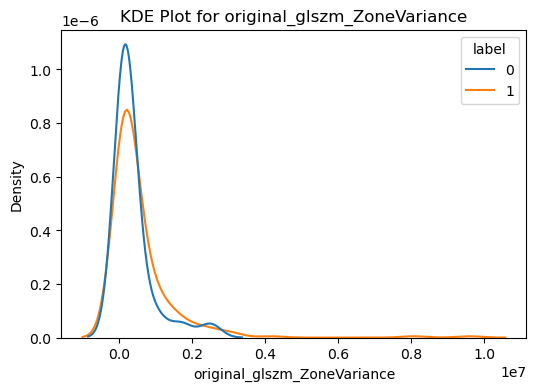

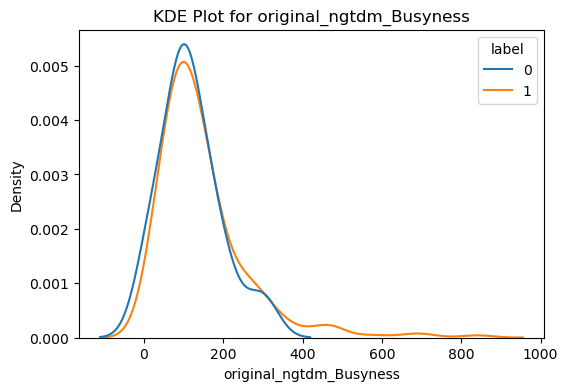

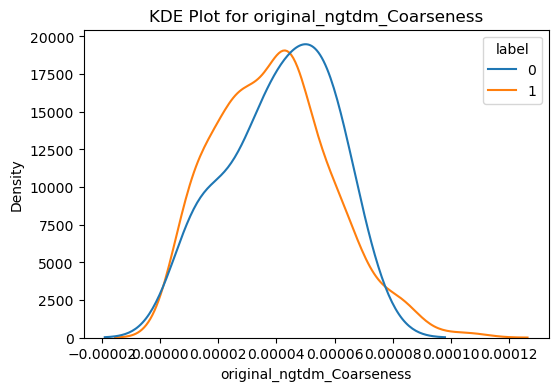

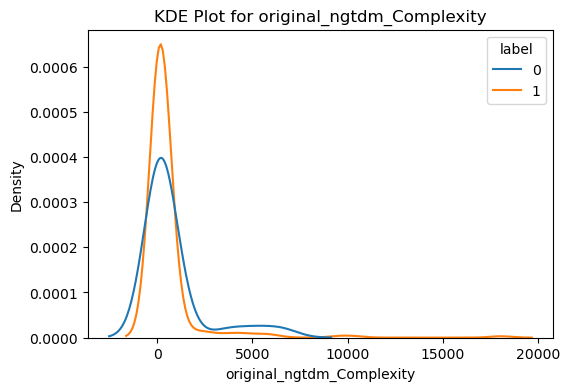

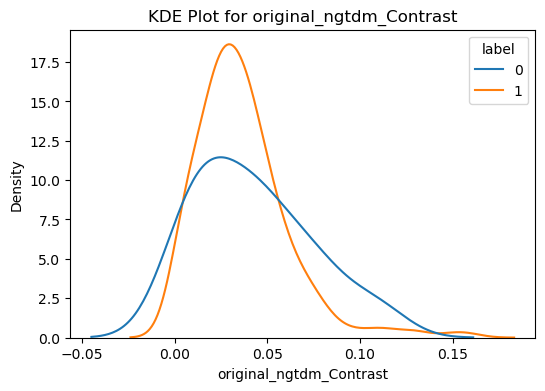

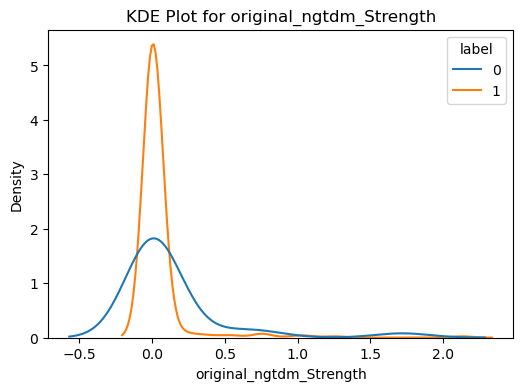

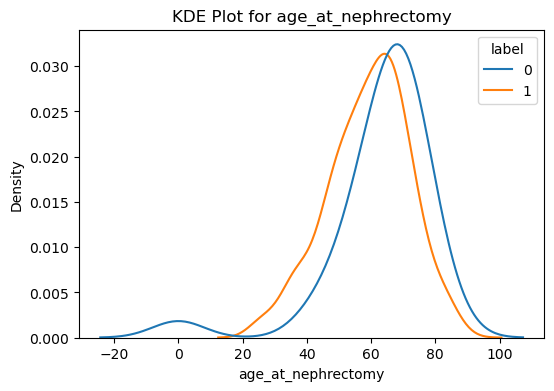

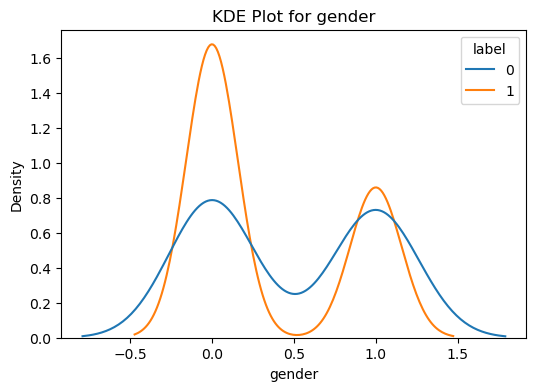

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from preprocess import preprocess_data

# Assuming preprocess_data returns the required splits as DataFrames/Series
X_train, X_test, y_train, y_test, case_id_train, case_id_test = preprocess_data('data/3D_KandT_Radiomics.csv')

# Concatenate features and labels for plotting
df_plot = X_train.copy()
df_plot['label'] = y_train

# Plot KDE for each feature, separated by label
for col in X_train.columns:
    plt.figure(figsize=(6, 4))
    sns.kdeplot(data=df_plot, x=col, hue='label', common_norm=False)
    plt.title(f'KDE Plot for {col}')
    plt.show()

### 做$t$-test找顯著差異的feature

In [3]:
from scipy.stats import ttest_ind

# Separate the two classes
class_0 = df_plot[df_plot['label'] == 0]
class_1 = df_plot[df_plot['label'] == 1]

# Store results
significant_features = []

# Test each feature (excluding 'label')
for feature in X_train.columns:
    # t-test (assume unequal variance)
    stat, pval = ttest_ind(class_0[feature], class_1[feature], equal_var=False, nan_policy='omit')
    if pval < 0.05:
        significant_features.append((feature, pval))

# Sort by p-value
significant_features.sort(key=lambda x: x[1])

# Display significant features and their p-values
for feature, pval in significant_features:
    print(f"{feature}: p-value = {pval:.4e}")

original_shape_LeastAxisLength: p-value = 7.1276e-05
original_shape_Flatness: p-value = 1.6343e-04
original_shape_VoxelVolume: p-value = 1.9481e-04
original_shape_MeshVolume: p-value = 1.9702e-04
original_shape_Elongation: p-value = 4.1090e-03
original_firstorder_Median: p-value = 6.6171e-03
original_shape_SurfaceVolumeRatio: p-value = 9.1767e-03
original_firstorder_Mean: p-value = 1.2052e-02
original_shape_Maximum2DDiameterSlice: p-value = 1.3585e-02
original_shape_SurfaceArea: p-value = 1.6549e-02
original_firstorder_RootMeanSquared: p-value = 2.0524e-02
original_glszm_LargeAreaLowGrayLevelEmphasis: p-value = 2.3179e-02
original_shape_MinorAxisLength: p-value = 2.4766e-02


#### 用顯著差異feature train SVM
- 結果偏全預測malignant

In [8]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix

# Extract feature names
selected_features = [f[0] for f in significant_features]

# Prepare training and test data using only significant features
X_train_sig = X_train[selected_features]
X_test_sig = X_test[selected_features]

# Train SVM classifier
svm = SVC(kernel='linear', random_state=42)
svm.fit(X_train_sig, y_train)

# Predict and evaluate
y_pred = svm.predict(X_test_sig)
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)
print("Classification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[ 0  7]
 [ 1 61]]
Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         7
           1       0.90      0.98      0.94        62

    accuracy                           0.88        69
   macro avg       0.45      0.49      0.47        69
weighted avg       0.81      0.88      0.84        69



#### 用顯著差異feature train SVM (with weight benign:9, malignant:1)
- benign更高機會預測到，malignant一半一半，整體差

In [7]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix

# Extract feature names
selected_features = [f[0] for f in significant_features]

# Prepare training and test data using only significant features
X_train_sig = X_train[selected_features]
X_test_sig = X_test[selected_features]

# Train SVM classifier
svm = SVC(kernel='linear', random_state=42, class_weight={0: 9, 1: 1} )
svm.fit(X_train_sig, y_train)

# Predict and evaluate
y_pred = svm.predict(X_test_sig)
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)
print("Classification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[ 6  1]
 [31 31]]
Classification Report:
              precision    recall  f1-score   support

           0       0.16      0.86      0.27         7
           1       0.97      0.50      0.66        62

    accuracy                           0.54        69
   macro avg       0.57      0.68      0.47        69
weighted avg       0.89      0.54      0.62        69



#### 繪製train, test predict prob kde plot
- benign, malignant都在threshold=0.9為高峰

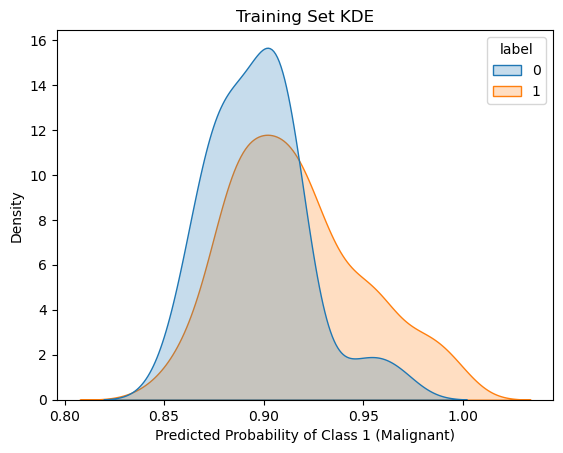

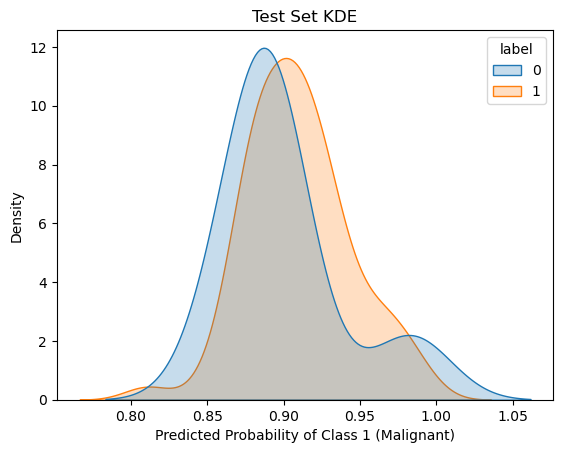

In [9]:
import numpy as np
import pandas as pd
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns

# Train SVM with probability output
svm = SVC(kernel='linear', random_state=42, probability=True)
svm.fit(X_train_sig, y_train)

# Get predicted probabilities for train and test
y_train_prob = svm.predict_proba(X_train_sig)[:, 1]
y_test_prob = svm.predict_proba(X_test_sig)[:, 1]

# === Plot KDE of predicted probabilities ===
def plot_kde_probs(y_true, y_prob, title):
    df_kde = pd.DataFrame({
        'probability': y_prob,
        'label': y_true
    })
    sns.kdeplot(data=df_kde, x='probability', hue='label', fill=True, common_norm=False)
    plt.title(title)
    plt.xlabel("Predicted Probability of Class 1 (Malignant)")
    plt.ylabel("Density")
    plt.show()

plot_kde_probs(y_train, y_train_prob, "Training Set KDE")
plot_kde_probs(y_test, y_test_prob, "Test Set KDE")

In [33]:
print(y_train_prob[:10])
print(y_test_prob[:10])

[0.94041726 0.92878526 0.87536718 0.92442353 0.88315105 0.86310389
 0.89355494 0.86277071 0.9524912  0.98271151]
[0.90230662 0.86363217 0.8738695  0.98317022 0.96759459 0.90703507
 0.97240093 0.8820639  0.86896269 0.88867932]


#### 測試不同threshold下的youden'j index
- 最佳threshold=0.9

In [ ]:
# Initialize results
thresholds = np.arange(0.0, 1.01, 0.01)
results = []

for threshold in thresholds:
    y_pred_thresh = (y_test_prob >= threshold).astype(int)

    acc = accuracy_score(y_test, y_pred_thresh)
    prec = precision_score(y_test, y_pred_thresh, zero_division=0)
    rec = recall_score(y_test, y_pred_thresh)
    f1 = f1_score(y_test, y_pred_thresh, average='macro')

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_thresh).ravel()
    specificity = tn / (tn + fp) if (tn + fp) != 0 else 0
    youden_j = rec + specificity - 1

    results.append({
        "threshold": threshold,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1_score": f1,
        "youden_j": youden_j
    })

df_threshold_metrics = pd.DataFrame(results)

# Display or save
print(df_threshold_metrics.head())
# Optionally save
df_threshold_metrics.to_csv("threshold_sweep_metrics.csv", index=False)

   threshold  accuracy  precision  recall  f1_score  youden_j
0       0.00  0.898551   0.898551     1.0  0.946565       0.0
1       0.01  0.898551   0.898551     1.0  0.946565       0.0
2       0.02  0.898551   0.898551     1.0  0.946565       0.0
3       0.03  0.898551   0.898551     1.0  0.946565       0.0
4       0.04  0.898551   0.898551     1.0  0.946565       0.0


In [12]:
best = df_threshold_metrics.loc[df_threshold_metrics["youden_j"].idxmax()]
print("\n🔍 Best Threshold by Youden's Index:")
print(best)


🔍 Best Threshold by Youden's Index:
threshold    0.900000
accuracy     0.623188
precision    0.973684
recall       0.596774
f1_score     0.740000
youden_j     0.453917
Name: 90, dtype: float64


### 統整grid search 3D radiomics 各個分類器的best hyperparameter set
- 步驟：
  - 基於AUC找到SVM, XGB, RF最佳的hyperparameter setting
  - 從最佳的hyperparameter setting的ROC_data
    - 以0~1以0.01為threshold間距，找到threshold使得macro f1 score為最大值
    - 以0~1以0.01為threshold間距，計算FAR, FRR，繪製x軸threshold, y軸error rate的圖，交叉點的x為EER threshold, y為EER value
  - 彙整grid search training的指標、最佳threshold及指標、EER value、EER threshold

- input
  - grid search訓練成果路徑：/Users/tingyanglu/Documents/Kidney/KiTS23/training_results下不同label的3D radiomics子folder
    - 3D_KandT_Radiomics
    - 3D_Kidney_Radiomics
    - 3D_Tumor_Radiomics
    - 3D_Kidney_Tumor_radiomics

- output
  - 個別classifier的資料夾：/Users/tingyanglu/Documents/Kidney/KiTS23/training_best_results/3D_KandT_Radiomics/XGB
    - {best_model}_threshold_sweep.csv
    - confusion_matrix.png
    - EER_plot.png
    - KDE_plot.png
  - 不同label的3D radiomics總整
    - best model summary: /Users/tingyanglu/Documents/Kidney/KiTS23/3D_radiomics_best_models_summary.csv
    - best model with best threshold summary: /Users/tingyanglu/Documents/Kidney/KiTS23/3D_radiomics_best_thresholds_summary.csv
    - summary(檔案在跑下面2D的結果被覆蓋，但不影響): /Users/tingyanglu/Documents/Kidney/KiTS23/training_best_results/summary.csv

- 彙整後的meeting用table: /Users/tingyanglu/Documents/RL/0721_0811_ML grid search performance.xlsx

In [30]:
import glob
import pandas as pd
import os
import numpy as np
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
import seaborn as sns

def find_best_models(datasets, models):
    """
    Find the best performing model for each dataset-model combination based on AUC.
    
    Args:
        datasets: List of dataset names
        models: List of model names
        
    Returns:
        list: Records of best models with their metrics
    """
    records = []
    
    for dataset in datasets:
        for model in models:
            pattern = f"training_results/{dataset}/{model}/*_overall_metrics.csv"
            csv_files = glob.glob(pattern)
            if not csv_files:
                continue

            best_auc = -1
            best_file = None
            best_df = None

            for file in csv_files:
                df = pd.read_csv(file)
                auc_row = df.loc[df['Metric'] == 'auc', 'Value']
                if auc_row.empty:
                    continue
                auc = auc_row.values[0]
                if auc > best_auc:
                    best_auc = auc
                    best_file = file
                    best_df = df

            if best_df is not None:
                acc = best_df.loc[best_df['Metric'] == 'accuracy', 'Value'].values[0]
                prec = best_df.loc[best_df['Metric'] == 'precision', 'Value'].values[0]
                rec = best_df.loc[best_df['Metric'] == 'recall', 'Value'].values[0]
                f1 = best_df.loc[best_df['Metric'] == 'f1_score', 'Value'].values[0]

                records.append({
                    "dataset": dataset,
                    "model": model,
                    "best_file": os.path.basename(best_file),
                    "auc": best_auc,
                    "accuracy": acc,
                    "precision": prec,
                    "recall": rec,
                    "f1_score": f1
                })
    
    return records

def optimize_thresholds(datasets, models):
    """
    Optimize classification thresholds for best models and calculate EER.
    
    Args:
        datasets: List of dataset names
        models: List of model names
        
    Returns:
        list: Records with optimized thresholds and EER information
    """
    records = []
    
    for dataset in datasets:
        for model in models:
            pattern = f"training_results/{dataset}/{model}/*_overall_metrics.csv"
            csv_files = glob.glob(pattern)
            if not csv_files:
                continue

            best_auc = -1
            best_file = None
            for file in csv_files:
                df = pd.read_csv(file)
                auc_row = df.loc[df['Metric'] == 'auc', 'Value']
                if auc_row.empty:
                    continue
                auc = auc_row.values[0]
                if auc > best_auc:
                    best_auc = auc
                    best_file = file

            if best_file is not None:
                # Find matching ROC data file
                roc_file = best_file.replace("_overall_metrics.csv", "_roc_data.csv")
                if os.path.exists(roc_file):
                    roc_df = pd.read_csv(roc_file)
                    y_true = roc_df["y_true"].values
                    y_prob = roc_df["y_prob"].values

                    thresholds = np.arange(0.0, 1.01, 0.01)
                    best_threshold = 0
                    best_f1 = -1
                    best_metrics = {}
                    eer_threshold = None
                    eer_value = None
                    min_eer_diff = float("inf")

                    for t in thresholds:
                        y_pred = (y_prob >= t).astype(int)
                        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
                        
                        acc = accuracy_score(y_true, y_pred)
                        prec = precision_score(y_true, y_pred, zero_division=0)
                        rec = recall_score(y_true, y_pred)
                        f1 = f1_score(y_true, y_pred, average="macro")
                        
                        fpr = fp / (fp + tn) if (fp + tn) != 0 else 0  # FAR
                        fnr = fn / (fn + tp) if (fn + tp) != 0 else 0  # FRR

                        if f1 > best_f1:
                            best_f1 = f1
                            best_threshold = t
                            best_metrics = {
                                "best_threshold_accuracy": acc,
                                "best_threshold_precision": prec,
                                "best_threshold_recall": rec,
                                "best_threshold_f1_score": f1
                            }
                        
                        # Calculate EER
                        if abs(fpr - fnr) < min_eer_diff:
                            min_eer_diff = abs(fpr - fnr)
                            eer_threshold = t
                            eer_value = (fpr + fnr) / 2

                    records.append({
                        "dataset": dataset,
                        "model": model,
                        "best_file": os.path.basename(best_file),
                        "best_auc": best_auc,
                        "best_threshold": best_threshold,
                        "eer_threshold": eer_threshold,
                        "eer_value": eer_value,
                        **best_metrics
                    })
    
    return records

def generate_analysis_plots(datasets, models):
    """
    Generate comprehensive analysis plots including EER curves, confusion matrices, and KDE plots.
    
    Args:
        datasets: List of dataset names
        models: List of model names
        
    Returns:
        list: Summary records with all analysis results
    """
    summary_records = []
    
    for dataset in datasets:
        for model in models:
            pattern = f"training_results/{dataset}/{model}/*_overall_metrics.csv"
            csv_files = glob.glob(pattern)
            if not csv_files:
                continue

            best_auc = -1
            best_file = None
            for file in csv_files:
                df = pd.read_csv(file)
                auc_row = df.loc[df['Metric'] == 'auc', 'Value']
                if auc_row.empty:
                    continue
                auc = auc_row.values[0]
                if auc > best_auc:
                    best_auc = auc
                    best_file = file

            if best_file is not None:
                roc_file = best_file.replace("_overall_metrics.csv", "_roc_data.csv")
                if os.path.exists(roc_file):
                    roc_df = pd.read_csv(roc_file)
                    y_true = roc_df["y_true"].values
                    y_prob = roc_df["y_prob"].values

                    thresholds = np.arange(0.0, 1.01, 0.01)
                    sweep_results = []
                    best_f1 = -1
                    best_threshold = 0
                    eer_threshold = None
                    eer_value = None
                    min_eer_diff = float("inf")

                    for t in thresholds:
                        y_pred = (y_prob >= t).astype(int)
                        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

                        acc = accuracy_score(y_true, y_pred)
                        prec = precision_score(y_true, y_pred, zero_division=0)
                        rec = recall_score(y_true, y_pred)
                        f1 = f1_score(y_true, y_pred, average="macro")

                        fpr = fp / (fp + tn) if (fp + tn) != 0 else 0  # FAR
                        fnr = fn / (fn + tp) if (fn + tp) != 0 else 0  # FRR

                        sweep_results.append({
                            "threshold": t,
                            "accuracy": acc,
                            "precision": prec,
                            "recall": rec,
                            "f1_macro": f1,
                            "FAR": fpr,
                            "FRR": fnr
                        })

                        if f1 > best_f1:
                            best_f1 = f1
                            best_threshold = t

                        if abs(fpr - fnr) < min_eer_diff:
                            min_eer_diff = abs(fpr - fnr)
                            eer_threshold = t
                            eer_value = (fpr + fnr) / 2

                    # Create output folder
                    out_dir = f"training_best_results/{dataset}/{model}"
                    os.makedirs(out_dir, exist_ok=True)

                    # Save threshold sweep CSV
                    sweep_df = pd.DataFrame(sweep_results)
                    sweep_csv = os.path.join(out_dir, os.path.basename(best_file).replace("_overall_metrics.csv", "_threshold_sweep.csv"))
                    sweep_df.to_csv(sweep_csv, index=False)
                    print(f"Saved threshold sweep: {sweep_csv}")

                    # === Plot EER Curve ===
                    plt.figure(figsize=(8, 5))
                    plt.plot(sweep_df["threshold"], sweep_df["FAR"], label="FAR (False Acceptance Rate)")
                    plt.plot(sweep_df["threshold"], sweep_df["FRR"], label="FRR (False Rejection Rate)")
                    plt.axvline(x=eer_threshold, color="gray", linestyle="--", label=f"EER Threshold = {eer_threshold:.2f}")
                    plt.axhline(y=eer_value, color="red", linestyle="--", label=f"EER = {eer_value:.2f}")
                    plt.title(f"EER Curve: {dataset} - {model}")
                    plt.xlabel("Threshold")
                    plt.ylabel("Error Rate")
                    plt.xlim(0, 1)
                    plt.ylim(0, 1)
                    plt.legend()
                    eer_plot_path = os.path.join(out_dir, "EER_plot.png")
                    plt.savefig(eer_plot_path, dpi=300, bbox_inches='tight')
                    plt.close()
                    print(f"Saved EER plot: {eer_plot_path}")

                    # === Plot Confusion Matrix at Best F1 Threshold ===
                    y_pred_best = (y_prob >= best_threshold).astype(int)
                    cm = confusion_matrix(y_true, y_pred_best)
                    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
                    disp.plot(cmap=plt.cm.Blues)
                    plt.title(f"Confusion Matrix ({dataset} - {model}) at Threshold = {best_threshold:.2f}")
                    cm_path = os.path.join(out_dir, "confusion_matrix.png")
                    plt.savefig(cm_path, dpi=300, bbox_inches='tight')
                    plt.close()
                    print(f"Saved confusion matrix: {cm_path}")

                    # === KDE Plot ===
                    plt.figure(figsize=(8, 5))
                    kde_df = pd.DataFrame({'probability': y_prob, 'label': y_true})
                    sns.kdeplot(data=kde_df, x='probability', hue='label', fill=True, common_norm=False)
                    plt.title(f"KDE of Predicted Probabilities ({dataset} - {model})")
                    plt.xlabel("Predicted Probability of Class 1 (Malignant)")
                    plt.ylabel("Density")
                    plt.xlim(0, 1)
                    kde_path = os.path.join(out_dir, "KDE_plot.png")
                    plt.savefig(kde_path, dpi=300, bbox_inches='tight')
                    plt.close()
                    print(f"Saved KDE plot: {kde_path}")

                    # Record summary for this model
                    summary_records.append({
                        "dataset": dataset,
                        "model": model,
                        "best_auc": best_auc,
                        "best_threshold_f1": best_threshold,
                        "best_f1": best_f1,
                        "eer_threshold": eer_threshold,
                        "eer_value": eer_value
                    })
    
    return summary_records

def main():
    """
    Main function to execute all analysis steps and generate output files.
    """
    # Define datasets and models
    datasets = [
        "3D_KandT_Radiomics",
        "3D_Kidney_Radiomics",
        "3D_Tumor_Radiomics",
        "3D_Kidney_Tumor_radiomics"
    ]
    models = ["RF", "SVM", "XGB"]
    
    print("Starting radiomics analysis...")
    print("="*50)
    
    # 1. Find best models based on AUC
    print("1. Finding best models based on AUC...")
    best_models = find_best_models(datasets, models)
    df_best_models = pd.DataFrame(best_models)
    
    # Save best models summary
    output_file1 = "3D_radiomics_best_models_summary.csv"
    df_best_models.to_csv(output_file1, index=False)
    print(f"Saved: {output_file1}")
    print(f"Found {len(best_models)} best model combinations")
    print()
    
    # 2. Optimize thresholds for best models
    print("2. Optimizing thresholds for best models...")
    threshold_results = optimize_thresholds(datasets, models)
    df_thresholds = pd.DataFrame(threshold_results)
    
    # Save threshold optimization results
    output_file2 = "3D_radiomics_best_thresholds_summary.csv"
    df_thresholds.to_csv(output_file2, index=False)
    print(f"Saved: {output_file2}")
    print(f"Optimized thresholds for {len(threshold_results)} model combinations")
    print()
    
    # 3. Generate comprehensive analysis plots
    print("3. Generating comprehensive analysis plots...")
    analysis_results = generate_analysis_plots(datasets, models)
    df_analysis = pd.DataFrame(analysis_results)
    
    # Save comprehensive summary
    os.makedirs("training_best_results", exist_ok=True)
    output_file3 = "training_best_results/summary.csv"
    df_analysis.to_csv(output_file3, index=False)
    print(f"Saved: {output_file3}")
    print(f"Generated plots and analysis for {len(analysis_results)} model combinations")
    print()
    
    print("Analysis complete!")
    print("="*50)
    print("Output files generated:")
    print(f"  - {output_file1}")
    print(f"  - {output_file2}")
    print(f"  - {output_file3}")
    print(f"  - Individual plots in training_best_results/[dataset]/[model]/ folders")
    
    # Display summary statistics
    print("\nSummary Statistics:")
    print(f"  - Total dataset-model combinations analyzed: {len(analysis_results)}")
    if len(analysis_results) > 0:
        print(f"  - Average AUC: {df_analysis['best_auc'].mean():.3f}")
        print(f"  - Average F1 Score: {df_analysis['best_f1'].mean():.3f}")
        print(f"  - Average EER: {df_analysis['eer_value'].mean():.3f}")

if __name__ == "__main__":
    main()

Starting radiomics analysis...
1. Finding best models based on AUC...
Saved: 3D_radiomics_best_models_summary.csv
Found 12 best model combinations

2. Optimizing thresholds for best models...
Saved: 3D_radiomics_best_thresholds_summary.csv
Optimized thresholds for 12 model combinations

3. Generating comprehensive analysis plots...
Saved threshold sweep: training_best_results/3D_KandT_Radiomics/RF/RF_max_depth=5_max_features=0.3_min_samples_leaf=10_min_samples_split=10_n_estimators=100_threshold_sweep.csv
Saved EER plot: training_best_results/3D_KandT_Radiomics/RF/EER_plot.png
Saved confusion matrix: training_best_results/3D_KandT_Radiomics/RF/confusion_matrix.png
Saved KDE plot: training_best_results/3D_KandT_Radiomics/RF/KDE_plot.png
Saved threshold sweep: training_best_results/3D_KandT_Radiomics/SVM/SVM_C=0.1_gamma=auto_kernel=linear_threshold_sweep.csv
Saved EER plot: training_best_results/3D_KandT_Radiomics/SVM/EER_plot.png
Saved confusion matrix: training_best_results/3D_KandT_Ra

#### 合併上面3個檔案做統整
- Input files:
  - /Users/tingyanglu/Documents/Kidney/KiTS23/3D_radiomics_best_models_summary.csv
  - /Users/tingyanglu/Documents/Kidney/KiTS23/3D_radiomics_best_thresholds_summary.csv
  - /Users/tingyanglu/Documents/Kidney/KiTS23/training_best_results/summary.csv
- Output files:
  - /Users/tingyanglu/Documents/Kidney/KiTS23/3D_radiomics_combined_analysis.xlsx

In [31]:
import pandas as pd
import os

def join_csv_files_to_xlsx():
    """
    Join three CSV files, remove duplicate columns, and save as Excel file.
    """
    # File paths
    file1 = "3D_radiomics_best_models_summary.csv"
    file2 = "3D_radiomics_best_thresholds_summary.csv"
    file3 = "training_best_results/summary.csv"
    
    # Check if files exist
    files_info = [
        (file1, "Best Models Summary"),
        (file2, "Best Thresholds Summary"),
        (file3, "Training Results Summary")
    ]
    
    missing_files = []
    for file_path, description in files_info:
        if not os.path.exists(file_path):
            missing_files.append(f"{description}: {file_path}")
    
    if missing_files:
        print("Missing files:")
        for missing in missing_files:
            print(f"  - {missing}")
        return
    
    # Read the CSV files
    print("Reading CSV files...")
    df1 = pd.read_csv(file1)
    df2 = pd.read_csv(file2)
    df3 = pd.read_csv(file3)
    
    print(f"File 1 shape: {df1.shape}")
    print(f"File 2 shape: {df2.shape}")
    print(f"File 3 shape: {df3.shape}")
    
    # Display column information
    print("\nColumn information:")
    print(f"File 1 columns: {list(df1.columns)}")
    print(f"File 2 columns: {list(df2.columns)}")
    print(f"File 3 columns: {list(df3.columns)}")
    
    # Start with the first dataframe as base
    merged_df = df1.copy()
    
    # Merge with second dataframe
    # Find common columns for merging
    common_cols_1_2 = ['dataset', 'model']
    if all(col in df1.columns and col in df2.columns for col in common_cols_1_2):
        # Get columns from df2 that are not in df1
        new_cols_from_df2 = [col for col in df2.columns if col not in df1.columns]
        if new_cols_from_df2:
            print(f"\nAdding columns from file 2: {new_cols_from_df2}")
            merged_df = pd.merge(merged_df, df2[common_cols_1_2 + new_cols_from_df2], 
                               on=common_cols_1_2, how='outer')
        else:
            print("\nNo new columns to add from file 2")
    
    # Merge with third dataframe
    common_cols_1_3 = ['dataset', 'model']
    if all(col in merged_df.columns and col in df3.columns for col in common_cols_1_3):
        # Get columns from df3 that are not in merged_df
        new_cols_from_df3 = [col for col in df3.columns if col not in merged_df.columns]
        if new_cols_from_df3:
            print(f"Adding columns from file 3: {new_cols_from_df3}")
            merged_df = pd.merge(merged_df, df3[common_cols_1_3 + new_cols_from_df3], 
                               on=common_cols_1_3, how='outer')
        else:
            print("No new columns to add from file 3")
    
    print(f"\nFinal merged dataframe shape: {merged_df.shape}")
    print(f"Final columns: {list(merged_df.columns)}")
    
    # Remove any remaining duplicate columns (if column names are exactly the same)
    merged_df = merged_df.loc[:, ~merged_df.columns.duplicated()]
    
    # Sort by dataset and model for better readability
    merged_df = merged_df.sort_values(['dataset', 'model']).reset_index(drop=True)
    
    # Save to Excel file
    output_file = "3D_radiomics_combined_analysis.xlsx"
    
    # Create Excel writer object
    with pd.ExcelWriter(output_file, engine='openpyxl') as writer:
        # Write the main combined data
        merged_df.to_excel(writer, sheet_name='Combined_Analysis', index=False)
        
        # Optionally, also include individual sheets for reference
        df1.to_excel(writer, sheet_name='Best_Models', index=False)
        df2.to_excel(writer, sheet_name='Best_Thresholds', index=False)
        df3.to_excel(writer, sheet_name='Training_Summary', index=False)
    
    print(f"\nExcel file saved: {output_file}")
    print(f"Sheets created:")
    print(f"  - Combined_Analysis: {merged_df.shape[0]} rows, {merged_df.shape[1]} columns")
    print(f"  - Best_Models: {df1.shape[0]} rows, {df1.shape[1]} columns")
    print(f"  - Best_Thresholds: {df2.shape[0]} rows, {df2.shape[1]} columns")
    print(f"  - Training_Summary: {df3.shape[0]} rows, {df3.shape[1]} columns")
    
    # Display sample of the merged data
    print(f"\nSample of combined data:")
    print(merged_df.head())
    
    # Check for any missing values
    missing_summary = merged_df.isnull().sum()
    missing_cols = missing_summary[missing_summary > 0]
    if len(missing_cols) > 0:
        print(f"\nColumns with missing values:")
        for col, count in missing_cols.items():
            print(f"  - {col}: {count} missing values")
    else:
        print(f"\nNo missing values found in the combined dataset")
    
    return merged_df

def analyze_combined_data(df):
    """
    Provide basic analysis of the combined dataset.
    """
    print("\n" + "="*50)
    print("COMBINED DATASET ANALYSIS")
    print("="*50)
    
    # Basic statistics
    print(f"Total records: {len(df)}")
    print(f"Total columns: {len(df.columns)}")
    
    # Dataset distribution
    if 'dataset' in df.columns:
        print(f"\nDataset distribution:")
        dataset_counts = df['dataset'].value_counts()
        for dataset, count in dataset_counts.items():
            print(f"  - {dataset}: {count} models")
    
    # Model distribution
    if 'model' in df.columns:
        print(f"\nModel distribution:")
        model_counts = df['model'].value_counts()
        for model, count in model_counts.items():
            print(f"  - {model}: {count} datasets")
    
    # Performance metrics summary
    numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
    performance_cols = [col for col in numeric_cols if any(metric in col.lower() 
                       for metric in ['auc', 'accuracy', 'precision', 'recall', 'f1', 'eer'])]
    
    if performance_cols:
        print(f"\nPerformance metrics summary:")
        for col in performance_cols:
            if col in df.columns:
                mean_val = df[col].mean()
                std_val = df[col].std()
                min_val = df[col].min()
                max_val = df[col].max()
                print(f"  - {col}:")
                print(f"    Mean: {mean_val:.4f}, Std: {std_val:.4f}")
                print(f"    Range: [{min_val:.4f}, {max_val:.4f}]")

if __name__ == "__main__":
    print("Joining CSV files and creating Excel output...")
    print("="*50)
    
    # Join the CSV files
    combined_df = join_csv_files_to_xlsx()
    
    if combined_df is not None:
        # Analyze the combined data
        analyze_combined_data(combined_df)
        
        print("\n" + "="*50)
        print("Process completed successfully!")
        print("="*50)
    else:
        print("Process failed due to missing files.")

Joining CSV files and creating Excel output...
Reading CSV files...
File 1 shape: (12, 8)
File 2 shape: (12, 11)
File 3 shape: (12, 7)

Column information:
File 1 columns: ['dataset', 'model', 'best_file', 'auc', 'accuracy', 'precision', 'recall', 'f1_score']
File 2 columns: ['dataset', 'model', 'best_file', 'best_auc', 'best_threshold', 'eer_threshold', 'eer_value', 'best_threshold_accuracy', 'best_threshold_precision', 'best_threshold_recall', 'best_threshold_f1_score']
File 3 columns: ['dataset', 'model', 'best_auc', 'best_threshold_f1', 'best_f1', 'eer_threshold', 'eer_value']

Adding columns from file 2: ['best_auc', 'best_threshold', 'eer_threshold', 'eer_value', 'best_threshold_accuracy', 'best_threshold_precision', 'best_threshold_recall', 'best_threshold_f1_score']
Adding columns from file 3: ['best_threshold_f1', 'best_f1']

Final merged dataframe shape: (12, 18)
Final columns: ['dataset', 'model', 'best_file', 'auc', 'accuracy', 'precision', 'recall', 'f1_score', 'best_auc',

### 2D radiomics model summary
- input
  - grid search訓練成果路徑：/Users/tingyanglu/Documents/Kidney/KiTS23/training_results下不同label的2D radiomics子folder
    - 2D_Kidney_Radiomics
    - 2D_Tumor_Radiomics

- output
  - 個別classifier的資料夾（以此為例）：/Users/tingyanglu/Documents/Kidney/KiTS23/training_best_results/2D_Kidney_Radiomics/XGB
    - {best_model}_threshold_sweep.csv
    - confusion_matrix.png
    - EER_plot.png
    - KDE_plot.png
  - 不同label的2D radiomics總整
    - /Users/tingyanglu/Documents/Kidney/KiTS23/2D_radiomics_best_models_summary.csv
    - /Users/tingyanglu/Documents/Kidney/KiTS23/2D_radiomics_best_thresholds_summary.csv
    - /Users/tingyanglu/Documents/Kidney/KiTS23/training_best_results/summary.csv

- 彙整後的meeting用table: /Users/tingyanglu/Documents/RL/0721_0811_ML grid search performance.xlsx

In [ ]:
import glob
import pandas as pd
import os
import numpy as np
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
import seaborn as sns

def find_best_models(datasets, models):
    """
    Find the best performing model for each dataset-model combination based on AUC.
    
    Args:
        datasets: List of dataset names
        models: List of model names
        
    Returns:
        list: Records of best models with their metrics
    """
    records = []
    
    for dataset in datasets:
        for model in models:
            pattern = f"training_results/{dataset}/{model}/*_overall_metrics.csv"
            csv_files = glob.glob(pattern)
            if not csv_files:
                continue

            best_auc = -1
            best_file = None
            best_df = None

            for file in csv_files:
                df = pd.read_csv(file)
                auc_row = df.loc[df['Metric'] == 'auc', 'Value']
                if auc_row.empty:
                    continue
                auc = auc_row.values[0]
                if auc > best_auc:
                    best_auc = auc
                    best_file = file
                    best_df = df

            if best_df is not None:
                acc = best_df.loc[best_df['Metric'] == 'accuracy', 'Value'].values[0]
                prec = best_df.loc[best_df['Metric'] == 'precision', 'Value'].values[0]
                rec = best_df.loc[best_df['Metric'] == 'recall', 'Value'].values[0]
                f1 = best_df.loc[best_df['Metric'] == 'f1_score', 'Value'].values[0]

                records.append({
                    "dataset": dataset,
                    "model": model,
                    "best_file": os.path.basename(best_file),
                    "auc": best_auc,
                    "accuracy": acc,
                    "precision": prec,
                    "recall": rec,
                    "f1_score": f1
                })
    
    return records

def optimize_thresholds(datasets, models):
    """
    Optimize classification thresholds for best models and calculate EER.
    
    Args:
        datasets: List of dataset names
        models: List of model names
        
    Returns:
        list: Records with optimized thresholds and EER information
    """
    records = []
    
    for dataset in datasets:
        for model in models:
            pattern = f"training_results/{dataset}/{model}/*_overall_metrics.csv"
            csv_files = glob.glob(pattern)
            if not csv_files:
                continue

            best_auc = -1
            best_file = None
            for file in csv_files:
                df = pd.read_csv(file)
                auc_row = df.loc[df['Metric'] == 'auc', 'Value']
                if auc_row.empty:
                    continue
                auc = auc_row.values[0]
                if auc > best_auc:
                    best_auc = auc
                    best_file = file

            if best_file is not None:
                # Find matching ROC data file
                roc_file = best_file.replace("_overall_metrics.csv", "_roc_data.csv")
                if os.path.exists(roc_file):
                    roc_df = pd.read_csv(roc_file)
                    y_true = roc_df["y_true"].values
                    y_prob = roc_df["y_prob"].values

                    thresholds = np.arange(0.0, 1.01, 0.01)
                    best_threshold = 0
                    best_f1 = -1
                    best_metrics = {}
                    eer_threshold = None
                    eer_value = None
                    min_eer_diff = float("inf")

                    for t in thresholds:
                        y_pred = (y_prob >= t).astype(int)
                        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
                        
                        acc = accuracy_score(y_true, y_pred)
                        prec = precision_score(y_true, y_pred, zero_division=0)
                        rec = recall_score(y_true, y_pred)
                        f1 = f1_score(y_true, y_pred, average="macro")
                        
                        fpr = fp / (fp + tn) if (fp + tn) != 0 else 0  # FAR
                        fnr = fn / (fn + tp) if (fn + tp) != 0 else 0  # FRR

                        if f1 > best_f1:
                            best_f1 = f1
                            best_threshold = t
                            best_metrics = {
                                "best_threshold_accuracy": acc,
                                "best_threshold_precision": prec,
                                "best_threshold_recall": rec,
                                "best_threshold_f1_score": f1
                            }
                        
                        # Calculate EER
                        if abs(fpr - fnr) < min_eer_diff:
                            min_eer_diff = abs(fpr - fnr)
                            eer_threshold = t
                            eer_value = (fpr + fnr) / 2

                    records.append({
                        "dataset": dataset,
                        "model": model,
                        "best_file": os.path.basename(best_file),
                        "best_auc": best_auc,
                        "best_threshold": best_threshold,
                        "eer_threshold": eer_threshold,
                        "eer_value": eer_value,
                        **best_metrics
                    })
    
    return records

def generate_analysis_plots(datasets, models):
    """
    Generate comprehensive analysis plots including EER curves, confusion matrices, and KDE plots.
    
    Args:
        datasets: List of dataset names
        models: List of model names
        
    Returns:
        list: Summary records with all analysis results
    """
    summary_records = []
    
    for dataset in datasets:
        for model in models:
            pattern = f"training_results/{dataset}/{model}/*_overall_metrics.csv"
            csv_files = glob.glob(pattern)
            if not csv_files:
                continue

            best_auc = -1
            best_file = None
            for file in csv_files:
                df = pd.read_csv(file)
                auc_row = df.loc[df['Metric'] == 'auc', 'Value']
                if auc_row.empty:
                    continue
                auc = auc_row.values[0]
                if auc > best_auc:
                    best_auc = auc
                    best_file = file

            if best_file is not None:
                roc_file = best_file.replace("_overall_metrics.csv", "_roc_data.csv")
                if os.path.exists(roc_file):
                    roc_df = pd.read_csv(roc_file)
                    y_true = roc_df["y_true"].values
                    y_prob = roc_df["y_prob"].values

                    thresholds = np.arange(0.0, 1.01, 0.01)
                    sweep_results = []
                    best_f1 = -1
                    best_threshold = 0
                    eer_threshold = None
                    eer_value = None
                    min_eer_diff = float("inf")

                    for t in thresholds:
                        y_pred = (y_prob >= t).astype(int)
                        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

                        acc = accuracy_score(y_true, y_pred)
                        prec = precision_score(y_true, y_pred, zero_division=0)
                        rec = recall_score(y_true, y_pred)
                        f1 = f1_score(y_true, y_pred, average="macro")

                        fpr = fp / (fp + tn) if (fp + tn) != 0 else 0  # FAR
                        fnr = fn / (fn + tp) if (fn + tp) != 0 else 0  # FRR

                        sweep_results.append({
                            "threshold": t,
                            "accuracy": acc,
                            "precision": prec,
                            "recall": rec,
                            "f1_macro": f1,
                            "FAR": fpr,
                            "FRR": fnr
                        })

                        if f1 > best_f1:
                            best_f1 = f1
                            best_threshold = t

                        if abs(fpr - fnr) < min_eer_diff:
                            min_eer_diff = abs(fpr - fnr)
                            eer_threshold = t
                            eer_value = (fpr + fnr) / 2

                    # Create output folder
                    out_dir = f"training_best_results/{dataset}/{model}"
                    os.makedirs(out_dir, exist_ok=True)

                    # Save threshold sweep CSV
                    sweep_df = pd.DataFrame(sweep_results)
                    sweep_csv = os.path.join(out_dir, os.path.basename(best_file).replace("_overall_metrics.csv", "_threshold_sweep.csv"))
                    sweep_df.to_csv(sweep_csv, index=False)
                    print(f"Saved threshold sweep: {sweep_csv}")

                    # === Plot EER Curve ===
                    plt.figure(figsize=(8, 5))
                    plt.plot(sweep_df["threshold"], sweep_df["FAR"], label="FAR (False Acceptance Rate)")
                    plt.plot(sweep_df["threshold"], sweep_df["FRR"], label="FRR (False Rejection Rate)")
                    plt.axvline(x=eer_threshold, color="gray", linestyle="--", label=f"EER Threshold = {eer_threshold:.2f}")
                    plt.axhline(y=eer_value, color="red", linestyle="--", label=f"EER = {eer_value:.2f}")
                    plt.title(f"EER Curve: {dataset} - {model}")
                    plt.xlabel("Threshold")
                    plt.ylabel("Error Rate")
                    plt.xlim(0, 1)
                    plt.ylim(0, 1)
                    plt.legend()
                    eer_plot_path = os.path.join(out_dir, "EER_plot.png")
                    plt.savefig(eer_plot_path, dpi=300, bbox_inches='tight')
                    plt.close()
                    print(f"Saved EER plot: {eer_plot_path}")

                    # === Plot Confusion Matrix at Best F1 Threshold ===
                    y_pred_best = (y_prob >= best_threshold).astype(int)
                    cm = confusion_matrix(y_true, y_pred_best)
                    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
                    disp.plot(cmap=plt.cm.Blues)
                    plt.title(f"Confusion Matrix ({dataset} - {model}) at Threshold = {best_threshold:.2f}")
                    cm_path = os.path.join(out_dir, "confusion_matrix.png")
                    plt.savefig(cm_path, dpi=300, bbox_inches='tight')
                    plt.close()
                    print(f"Saved confusion matrix: {cm_path}")

                    # === KDE Plot ===
                    plt.figure(figsize=(8, 5))
                    kde_df = pd.DataFrame({'probability': y_prob, 'label': y_true})
                    sns.kdeplot(data=kde_df, x='probability', hue='label', fill=True, common_norm=False)
                    plt.title(f"KDE of Predicted Probabilities ({dataset} - {model})")
                    plt.xlabel("Predicted Probability of Class 1 (Malignant)")
                    plt.ylabel("Density")
                    plt.xlim(0, 1)
                    kde_path = os.path.join(out_dir, "KDE_plot.png")
                    plt.savefig(kde_path, dpi=300, bbox_inches='tight')
                    plt.close()
                    print(f"Saved KDE plot: {kde_path}")

                    # Record summary for this model
                    summary_records.append({
                        "dataset": dataset,
                        "model": model,
                        "best_auc": best_auc,
                        "best_threshold_f1": best_threshold,
                        "best_f1": best_f1,
                        "eer_threshold": eer_threshold,
                        "eer_value": eer_value
                    })
    
    return summary_records

def main():
    """
    Main function to execute all analysis steps and generate output files.
    """
    # Define datasets and models
    datasets = [
        "2D_Kidney_Radiomics",
        "2D_Tumor_Radiomics",
    ]
    models = ["RF", "SVM", "XGB"]
    
    print("Starting radiomics analysis...")
    print("="*50)
    
    # 1. Find best models based on AUC
    print("1. Finding best models based on AUC...")
    best_models = find_best_models(datasets, models)
    df_best_models = pd.DataFrame(best_models)
    
    # Save best models summary
    output_file1 = "2D_radiomics_best_models_summary.csv"
    df_best_models.to_csv(output_file1, index=False)
    print(f"Saved: {output_file1}")
    print(f"Found {len(best_models)} best model combinations")
    print()
    
    # 2. Optimize thresholds for best models
    print("2. Optimizing thresholds for best models...")
    threshold_results = optimize_thresholds(datasets, models)
    df_thresholds = pd.DataFrame(threshold_results)
    
    # Save threshold optimization results
    output_file2 = "2D_radiomics_best_thresholds_summary.csv"
    df_thresholds.to_csv(output_file2, index=False)
    print(f"Saved: {output_file2}")
    print(f"Optimized thresholds for {len(threshold_results)} model combinations")
    print()
    
    # 3. Generate comprehensive analysis plots
    print("3. Generating comprehensive analysis plots...")
    analysis_results = generate_analysis_plots(datasets, models)
    df_analysis = pd.DataFrame(analysis_results)
    
    # Save comprehensive summary
    os.makedirs("training_best_results", exist_ok=True)
    output_file3 = "training_best_results/summary.csv"
    df_analysis.to_csv(output_file3, index=False)
    print(f"Saved: {output_file3}")
    print(f"Generated plots and analysis for {len(analysis_results)} model combinations")
    print()
    
    print("Analysis complete!")
    print("="*50)
    print("Output files generated:")
    print(f"  - {output_file1}")
    print(f"  - {output_file2}")
    print(f"  - {output_file3}")
    print(f"  - Individual plots in training_best_results/[dataset]/[model]/ folders")
    
    # Display summary statistics
    print("\nSummary Statistics:")
    print(f"  - Total dataset-model combinations analyzed: {len(analysis_results)}")
    if len(analysis_results) > 0:
        print(f"  - Average AUC: {df_analysis['best_auc'].mean():.3f}")
        print(f"  - Average F1 Score: {df_analysis['best_f1'].mean():.3f}")
        print(f"  - Average EER: {df_analysis['eer_value'].mean():.3f}")

if __name__ == "__main__":
    main()

Starting radiomics analysis...
1. Finding best models based on AUC...
Saved: 2D_radiomics_best_models_summary.csv
Found 6 best model combinations

2. Optimizing thresholds for best models...
Saved: 2D_radiomics_best_thresholds_summary.csv
Optimized thresholds for 6 model combinations

3. Generating comprehensive analysis plots...
Saved threshold sweep: training_best_results/2D_Kidney_Radiomics/RF/RF_max_depth=10_max_features=0.3_min_samples_leaf=5_min_samples_split=10_n_estimators=200_threshold_sweep.csv
Saved EER plot: training_best_results/2D_Kidney_Radiomics/RF/EER_plot.png
Saved confusion matrix: training_best_results/2D_Kidney_Radiomics/RF/confusion_matrix.png
Saved KDE plot: training_best_results/2D_Kidney_Radiomics/RF/KDE_plot.png
Saved threshold sweep: training_best_results/2D_Kidney_Radiomics/SVM/SVM_C=10.0_gamma=0.1_kernel=rbf_threshold_sweep.csv
Saved EER plot: training_best_results/2D_Kidney_Radiomics/SVM/EER_plot.png
Saved confusion matrix: training_best_results/2D_Kidney_

### 做csv儲存3D radiomics訓練時分的5 fold train/test case_id和fold順序
- 用途：  
  實驗用U-net kidney segmentation model 取2D radiomics 每個slice 在bottleneck 的 embedding  
  把做5-fold CV的每個test fold case先拼成一個h5檔，再訓練用embedding當input的ML model跟2D radiomics訓練結果比較

In [1]:
import pandas as pd

# Paths
embedding_csv = '/Users/tingyanglu/Documents/Kidney/KiTS23/data/2D_Tumor_Embedding.csv'
roc_csv = '/Users/tingyanglu/Documents/Kidney/KiTS23/training_results/3D_KandT_Radiomics/RF/RF_max_depth=5_max_features=0.3_min_samples_leaf=5_min_samples_split=10_n_estimators=100_roc_details.csv'

# Load CSVs
df_embedding = pd.read_csv(embedding_csv)
df_roc = pd.read_csv(roc_csv)


In [6]:
# Add new columns
df_embedding['train'] = False         # Default as training
df_embedding['fold'] = None          # Default as no fold

# Iterate through each row of df_roc to assign test fold
for _, row in df_roc.iterrows():
    # Skip rows that aren't fold definitions
    if isinstance(row['Fold'], str) and row['Fold'].startswith('Fold'):
        fold_num = row['Fold'].split(' ')[1]  # e.g., "Fold 0" -> "0"
        case_ids = row['Case_IDs'].split(',')  # Split case ID string

        for case_id in case_ids:
            # print(case_id)
            mask = df_embedding['case_id'] == case_id
            df_embedding.loc[mask, 'train'] = True
            df_embedding.loc[mask, 'fold'] = fold_num

# Optional: convert 'fold' column to integer
df_embedding['fold'] = df_embedding['fold'].astype('Int64')

# Preview
print(df_embedding[['case_id', 'train', 'fold']].head())

      case_id  train  fold
0  case_00000   True     3
1  case_00004  False  <NA>
2  case_00005   True     1
3  case_00006   True     1
4  case_00007  False  <NA>


In [7]:
df_embedding.to_csv(embedding_csv, index=False)
print(f"Updated {embedding_csv} with train/test split and fold information.")

Updated /Users/tingyanglu/Documents/Kidney/KiTS23/data/2D_Tumor_Embedding.csv with train/test split and fold information.


### 用Training best file and threshold 和testing roc data測得使用best threshold在testing 的performance

In [12]:
import pandas as pd
import os
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score, 
    recall_score, f1_score, roc_auc_score
)

# Configuration paths
test_result_path = '/Users/tingyanglu/Documents/Kidney/KiTS23/testing_results'
best_test_result_path = '/Users/tingyanglu/Documents/Kidney/KiTS23/testing_best_results'
best_file_threshold_path = '/Users/tingyanglu/Documents/Kidney/KiTS23/training_best_results/best_training_file_threshold.csv'
result_save_path = '/Users/tingyanglu/Documents/Kidney/KiTS23/testing_best_results/best_testing_results.csv'

def calculate_metrics(y_true, y_prob, threshold):
    """Calculate comprehensive evaluation metrics"""
    y_pred = (y_prob >= threshold).astype(int)
    
    # Confusion matrix
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    
    # Calculate metrics
    acc = round(accuracy_score(y_true, y_pred), 3)
    prec = round(precision_score(y_true, y_pred, zero_division=0), 3)
    rec = round(recall_score(y_true, y_pred, zero_division=0), 3)
    f1 = round(f1_score(y_true, y_pred, zero_division=0), 3)
    auc = round(roc_auc_score(y_true, y_prob), 3)
    
    return {
        'accuracy': acc, 'precision': prec, 'recall': rec, 'f1_score': f1, 'auc': auc,
        'tn': tn, 'fp': fp, 'fn': fn, 'tp': tp
    }

def main():
    # Ensure output directory exists
    os.makedirs(best_test_result_path, exist_ok=True)
    
    # Read best model configurations
    try:
        best_file_threshold_df = pd.read_csv(best_file_threshold_path)
    except FileNotFoundError:
        print(f"Error: Best threshold file not found at {best_file_threshold_path}")
        return
    
    all_results = []
    
    print("Starting model evaluation...")
    
    for _, row in best_file_threshold_df.iterrows():
        dataset = row['dataset']
        model = row['model']
        best_threshold = row['best_threshold']
        best_file = row['best_file']
        
        # Construct ROC file path
        roc_file = os.path.join(
            test_result_path, dataset, model,
            best_file.replace("_overall_metrics.csv", "_roc_data.csv")
        )
        
        print(f"Processing: {dataset} - {model}")
        
        if not os.path.exists(roc_file):
            print(f"ROC data file not found. Skipping...")
            continue
        
        try:
            # Load ROC data
            roc_df = pd.read_csv(roc_file)
            
            # Validate required columns
            if not all(col in roc_df.columns for col in ['y_true', 'y_prob']):
                print(f"Required columns not found. Skipping...")
                continue
            
            y_true = roc_df["y_true"].values
            y_prob = roc_df["y_prob"].values
            
            # Calculate metrics
            metrics = calculate_metrics(y_true, y_prob, best_threshold)
            
            # Print results
            print(f"Threshold: {best_threshold:.4f} | Acc: {metrics['accuracy']:.3f} | "
                  f"Prec: {metrics['precision']:.3f} | Rec: {metrics['recall']:.3f} | "
                  f"F1: {metrics['f1_score']:.3f} | AUC: {metrics['auc']:.3f}")
            
            # Prepare result record
            result_record = {
                'dataset': dataset, 'model': model, 'best_threshold': best_threshold,
                **metrics
            }
            all_results.append(result_record)
            
            # Save individual result
            individual_dir = os.path.join(best_test_result_path, dataset, model)
            os.makedirs(individual_dir, exist_ok=True)
            
            individual_file = os.path.join(
                individual_dir, 
                best_file.replace("_overall_metrics.csv", "_test_results.csv")
            )
            pd.DataFrame([result_record]).to_csv(individual_file, index=False)
            
        except Exception as e:
            print(f"Error processing {roc_file}: {str(e)}")
    
    # Save consolidated results
    if all_results:
        pd.DataFrame(all_results).to_csv(result_save_path, index=False)
        print(f"\nConsolidated results saved to {result_save_path}")
    else:
        print("No results to save - all files were skipped or had errors.")
    
    print(f"Testing completed for {len(all_results)} model configurations.")

if __name__ == "__main__":
    main()

Starting model evaluation...
Processing: 3D_KandT_Radiomics - RF
Threshold: 0.7800 | Acc: 0.855 | Prec: 0.933 | Rec: 0.903 | F1: 0.918 | AUC: 0.560
Processing: 3D_KandT_Radiomics - SVM
Threshold: 0.8700 | Acc: 0.899 | Prec: 0.899 | Rec: 1.000 | F1: 0.947 | AUC: 0.569
Processing: 3D_KandT_Radiomics - XGB
Threshold: 0.9700 | Acc: 0.725 | Prec: 0.922 | Rec: 0.758 | F1: 0.832 | AUC: 0.551
Processing: 3D_Kidney_Radiomics - RF
Threshold: 0.7700 | Acc: 0.870 | Prec: 0.908 | Rec: 0.952 | F1: 0.929 | AUC: 0.442
Processing: 3D_Kidney_Radiomics - SVM
Threshold: 0.8900 | Acc: 0.696 | Prec: 0.902 | Rec: 0.742 | F1: 0.814 | AUC: 0.429
Processing: 3D_Kidney_Radiomics - XGB
Threshold: 0.9100 | Acc: 0.812 | Prec: 0.915 | Rec: 0.871 | F1: 0.893 | AUC: 0.553
Processing: 3D_Tumor_Radiomics - RF
Threshold: 0.8300 | Acc: 0.667 | Prec: 0.882 | Rec: 0.726 | F1: 0.796 | AUC: 0.560
Processing: 3D_Tumor_Radiomics - SVM
Threshold: 0.8800 | Acc: 0.870 | Prec: 0.908 | Rec: 0.952 | F1: 0.929 | AUC: 0.440
Processing: